# Fire & Smoke Detection — 01 · Training and Model Comparison

**Object Detection Final Project — DOTPY Academy**
Majid · MST · YOLO11n · Transfer Learning

---

### What this notebook does

Downloads the dataset, fine-tunes YOLO11n from pretrained COCO weights **twice**
with different settings, and compares the two runs. It saves the weights to
Google Drive so that no later step ever needs to retrain.

**Run time: roughly 4 hours on a Tesla T4.** Run it once.

Evaluation, threshold calibration, unseen-image testing and the demo live in
notebook **02**, which loads the saved weights and runs in minutes. The two
notebooks are split for exactly that reason: retraining a model to look at its
metrics again wastes four hours of GPU time.

### Pipeline

`Roboflow dataset → YOLO11n pretrained weights → fine-tune → evaluate → save to Drive`

## 1 · Environment

Ultralytics provides YOLO11 and the training loop.

In [ ]:
# تثبيت مكتبة Ultralytics الرسمية لـ YOLO
!pip install ultralytics roboflow

import os
from ultralytics import YOLO

# التأكد من التوصيل بالـ GPU
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26

## 2 · Dataset

**Fire-smoke Detection** — Roboflow Universe, workspace `detection-projet`,
project `fire-smoke-detection-lk8z9`, version 1, exported in YOLO format.

Already annotated with bounding boxes, so no manual annotation was needed. The
download creates `/content/Fire--smoke-Detection-1/` with `train`, `valid` and
`test` folders plus `data.yaml`.

In [ ]:
# The dataset is a public set on Roboflow Universe:
#   https://universe.roboflow.com/detection-projet/fire-smoke-detection-lk8z9
# Put your own key in Colab Secrets (key icon in the left sidebar) named ROBOFLOW_KEY.
!pip install -q roboflow

from google.colab import userdata
from roboflow import Roboflow

rf      = Roboflow(api_key=userdata.get("ROBOFLOW_KEY"))
project = rf.workspace("detection-projet").project("fire-smoke-detection-lk8z9")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire--smoke-Detection-1 in yolov8:: 100%|██████████| 24266/24266 [00:03<00:00, 8083.85it/s] 


## 3 · Training run 1 — 20 epochs

Transfer learning: training starts from `yolo11n.pt`, the nano checkpoint
pretrained on COCO. The early layers already encode edges, textures and shapes,
so only the fire and smoke distinction has to be learned.

**Why nano:** it trains in under an hour on a free GPU, leaving time for
evaluation, and is fast enough to run the video demo.

Settings: `epochs=20`, `imgsz=640`, `batch=32`.

In [ ]:
# Cell 3: fine-tune_yolo_model (التدريب السريع - 20 Epochs)
from ultralytics import YOLO

# 1. تحميل أوزان النموذج المصغر
model = YOLO("yolo11n.pt")

# 2. بدء التدريب المحدد بساعة واحدة
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=20,       # تخفيض العصور لإنهاء التدريب في ~50-60 دقيقة
    imgsz=640,
    batch=32,        # زيادتها لـ 32 لاستغلال الـ GPU بشكل أسرع
    name="fire_smoke_model",
    project="results",
    exist_ok=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fire--smoke-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_model, nb

## 4 · Run 1 — training curves and confusion matrix

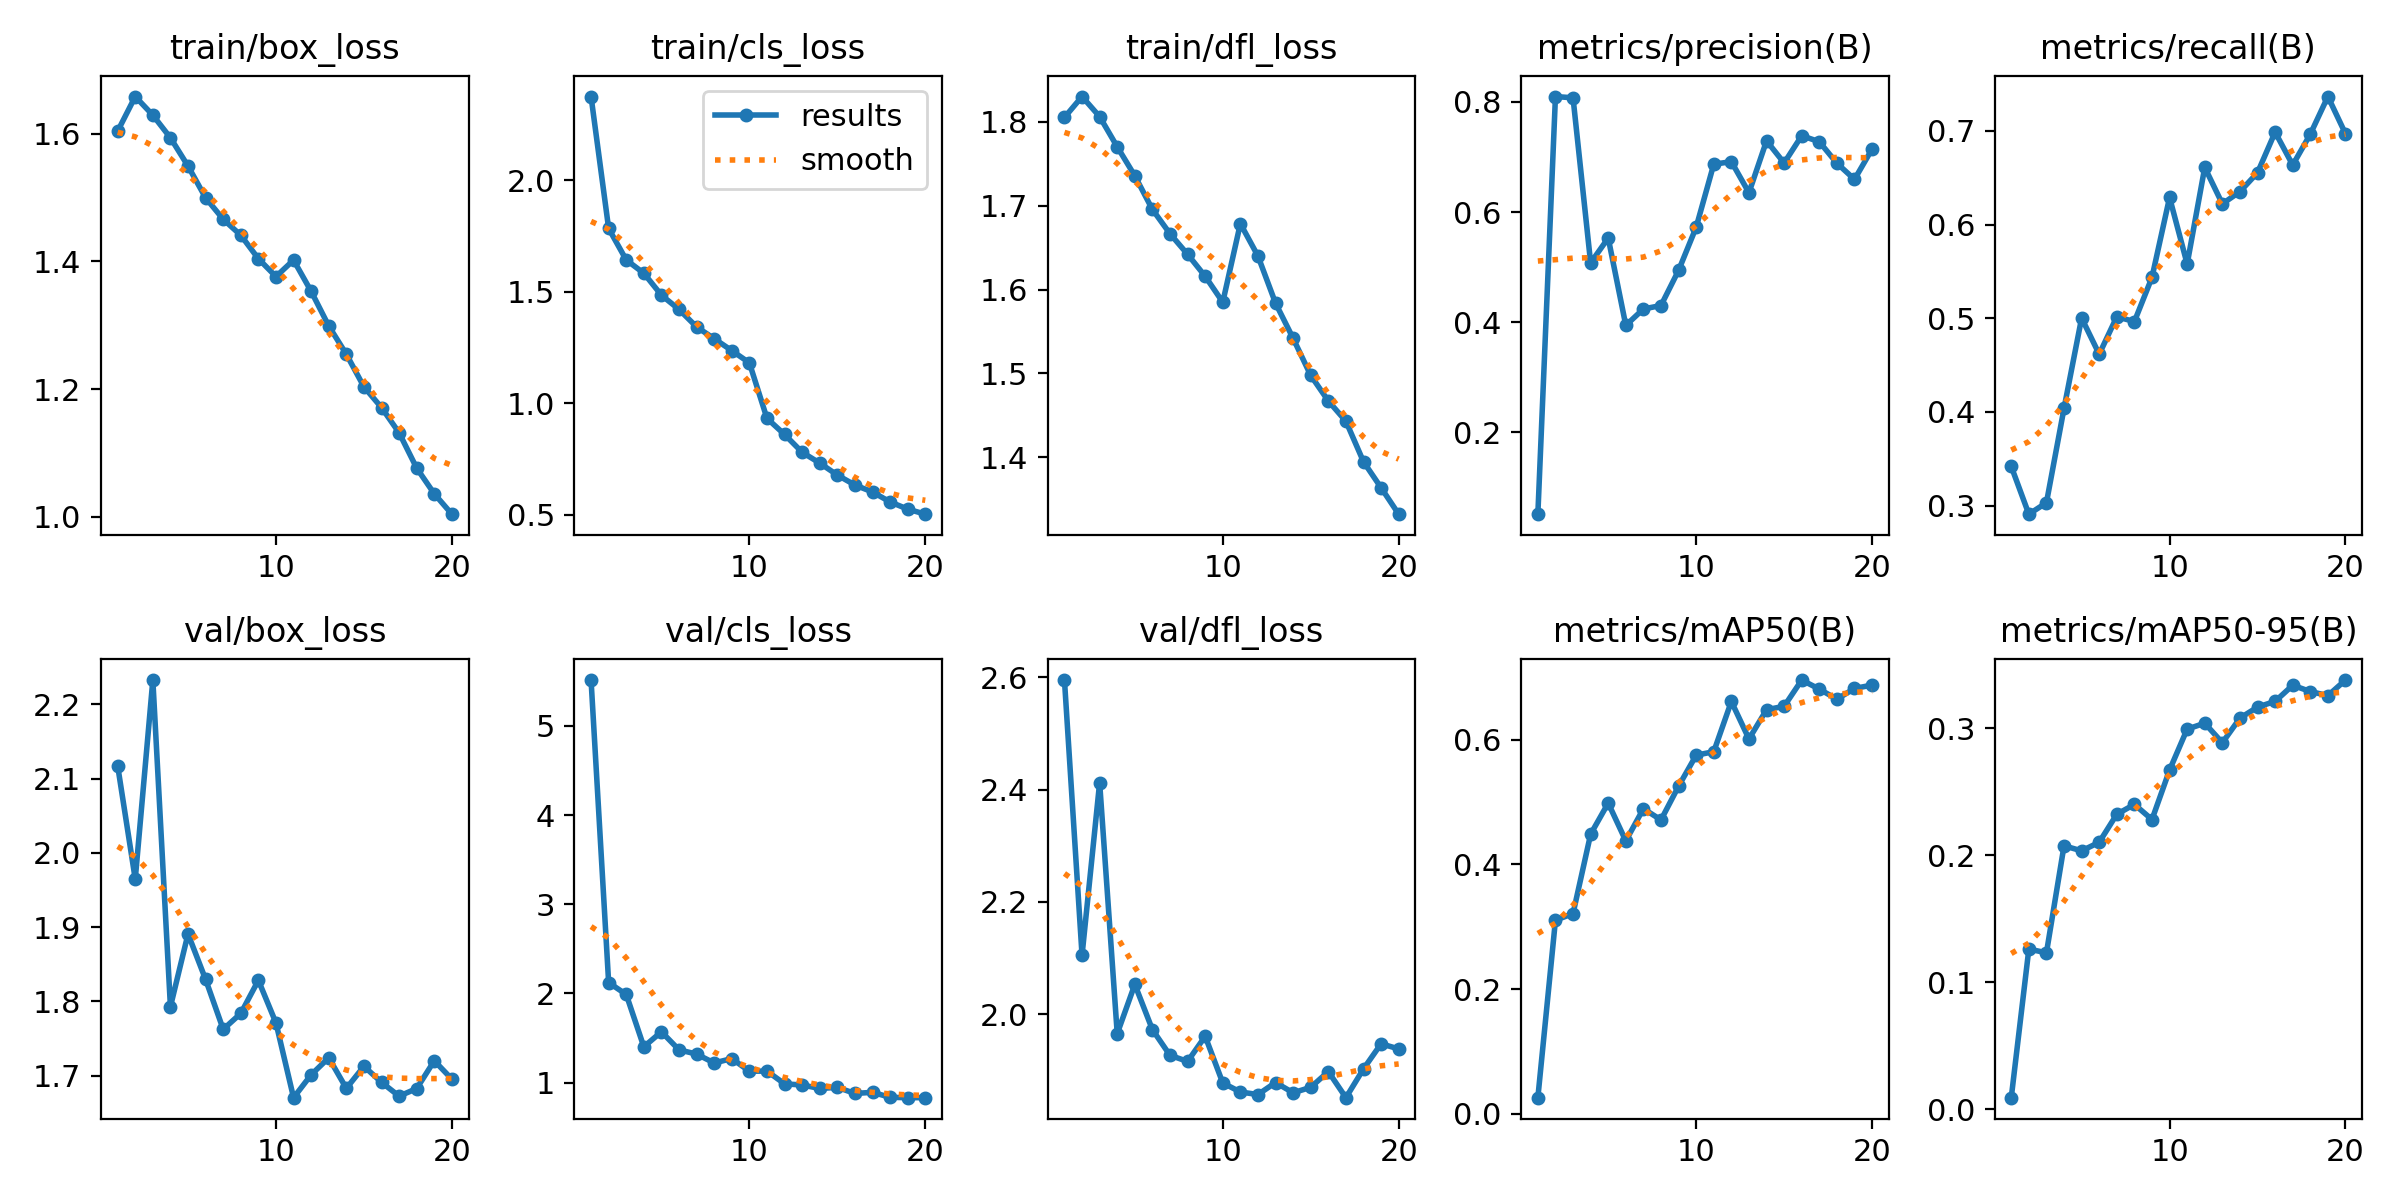

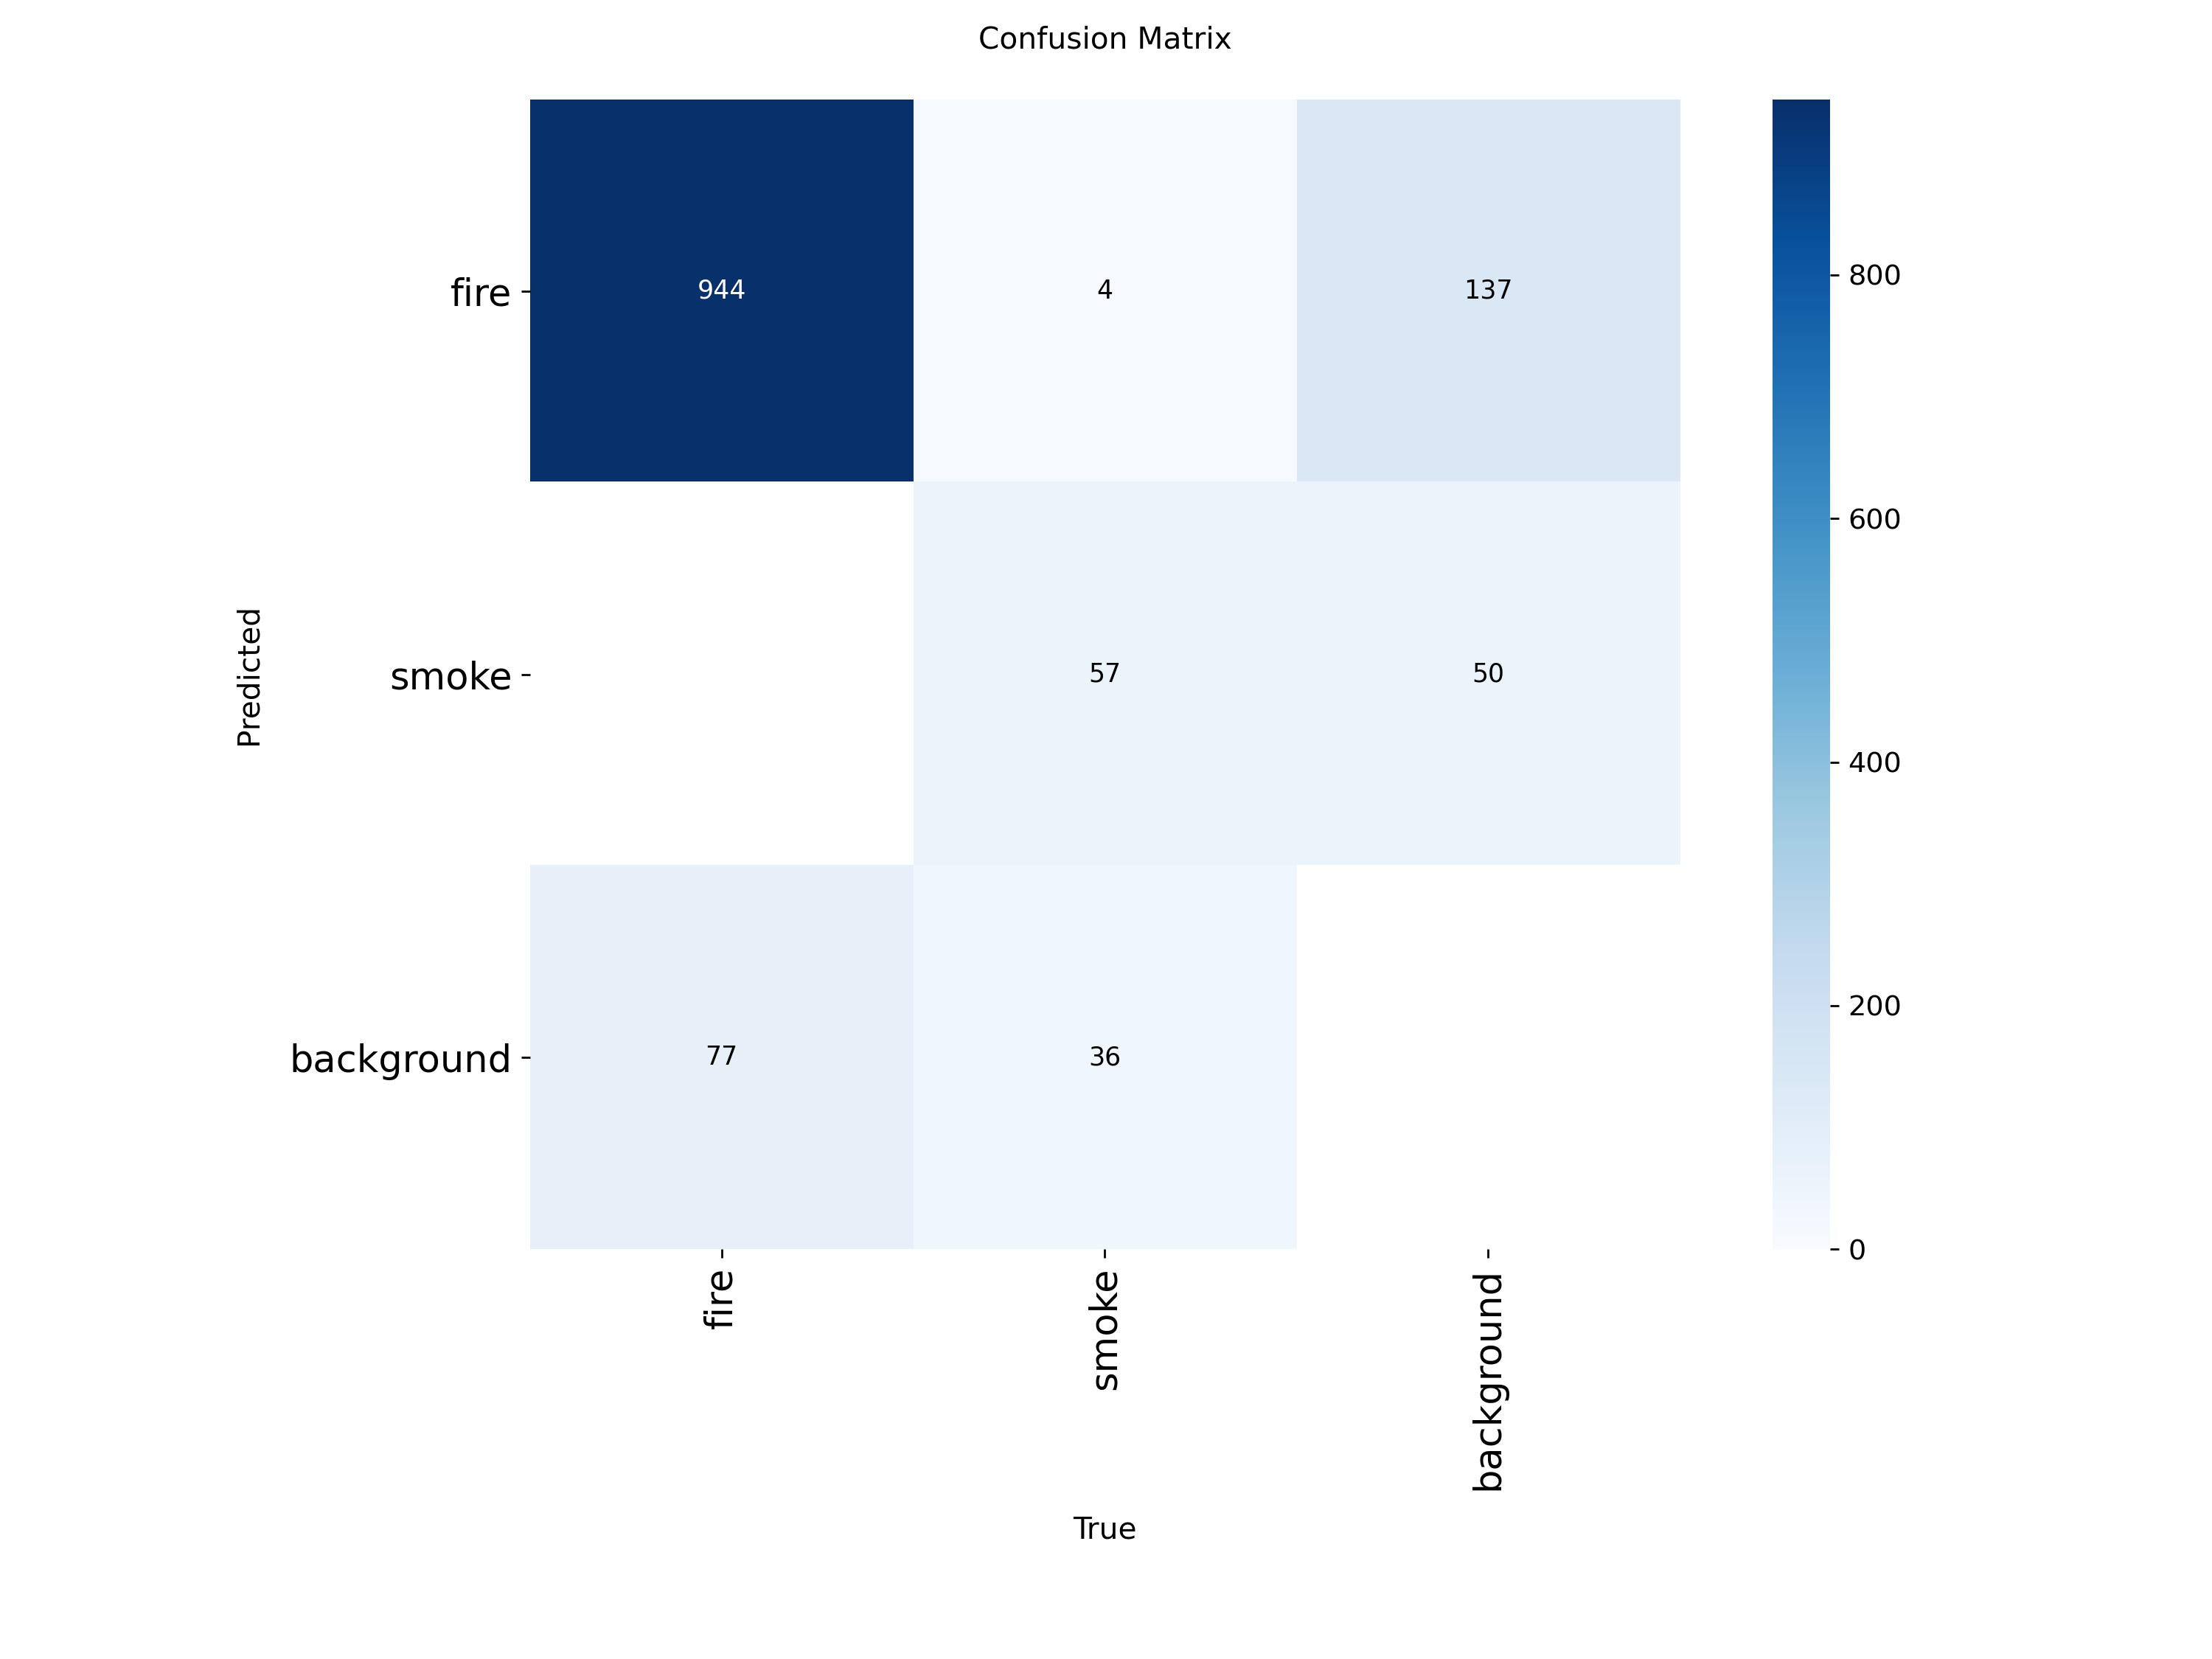

In [ ]:
# ==========================================
# 📊 عرض منحنيات الأداء ومصفوفة الارتباك
# ==========================================

from IPython.display import Image, display

# عرض منحنيات النتائج والدقة
display(Image(filename="/content/runs/detect/results/fire_smoke_model/results.png"))

# عرض مصفوفة الارتباك
display(Image(filename="/content/runs/detect/results/fire_smoke_model/confusion_matrix.png"))

## 5 · Save run 1 weights to Drive

Everything under `/content` disappears when the Colab session ends. Weights go
to Drive so notebook 02 can load them without retraining.

In [ ]:
import os
import shutil
from google.colab import drive

# 1. التأكد من ربط Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. مسار الحفظ في Drive
drive_folder = "/content/drive/MyDrive/YOLO11_Fire_Smoke"
os.makedirs(drive_folder, exist_ok=True)

# 3. مسار الملف الناتج من التدريب في Colab
local_best_path = "/content/runs/detect/results/fire_smoke_model/weights/best.pt"

# 4. نقل الملف إلى Drive
if os.path.exists(local_best_path):
    shutil.copy(local_best_path, f"{drive_folder}/best.pt")
    print("✅ تم حفظ الملف بنجاح في Google Drive!")
else:
    print("⚠️ لم يتم العثور على ملف best.pt في مسار التدريب المحتلي، يرجى التأكد من عدم إعادة تشغيل الجلسة (Runtime).")

Mounted at /content/drive
✅ تم حفظ الملف بنجاح في Google Drive!


## 6 · Run 1 — evaluation on the test split

`split="test"` uses images held out from both training and validation.

In [ ]:
from ultralytics import YOLO

# تحميل النموذج من Google Drive
model = YOLO("/content/drive/MyDrive/YOLO11_Fire_Smoke/best.pt")

# تشغيل التقييم على مجلد الاختبار
results = model.val(data="/content/Fire--smoke-Detection-1/data.yaml", split="test")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 13.0±4.9 MB/s, size: 39.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/Fire--smoke-Detection-1/test/labels... 521 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 521/521 979.1it/s 0.5s
val: New cache created: /content/Fire--smoke-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 4.8it/s 6.9s
                   all        521        578      0.739      0.722       0.71      0.336
                  fire        445        479      0.869      0.889      0.914      0.482
                 smoke         99         99       0.61      0.556      0.50

## 7 · Run 1 — visual predictions on test images

Annotated images are written to `inference_results/test_predictions/`.

In [ ]:
# إجراء تنبؤ على مجلد صور الاختبار وحفظ النتائج
model.predict(
    source="/content/Fire--smoke-Detection-1/test/images",
    save=True,
    conf=0.25,
    project="inference_results",
    name="test_predictions"
)


image 1/521 /content/Fire--smoke-Detection-1/test/images/-2022-05-30-203034_png_aug1_jpg.rf.bdda265ac3281d9c9d9f5639ce6a5a5c.jpg: 640x640 1 fire, 15.0ms
image 2/521 /content/Fire--smoke-Detection-1/test/images/-2022-05-30-203034_png_aug2_jpg.rf.75e961081799aa98246e8e63f7ee3715.jpg: 640x640 1 fire, 11.7ms
image 3/521 /content/Fire--smoke-Detection-1/test/images/-2022-05-30-203034_png_aug3_jpg.rf.2c2e20636b1e589e10c2db3d1ea9a0c8.jpg: 640x640 1 fire, 12.2ms
image 4/521 /content/Fire--smoke-Detection-1/test/images/-2022-05-30-203034_png_jpg.rf.f68a786db41e884285b5c0c9677a07f4.jpg: 640x640 1 fire, 10.3ms
image 5/521 /content/Fire--smoke-Detection-1/test/images/000155_aug1_jpg.rf.ef3d3467460688114c243ac74ba5232e.jpg: 640x640 1 smoke, 9.9ms
image 6/521 /content/Fire--smoke-Detection-1/test/images/000155_aug2_jpg.rf.efda6bf56e1774b86320d322788eaf68.jpg: 640x640 1 smoke, 12.5ms
image 7/521 /content/Fire--smoke-Detection-1/test/images/000155_aug3_jpg.rf.c79ed79374dea06c883acd2a29bde8f2.jpg: 640

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'fire', 1: 'smoke'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],


## 8 · Run 1 — evaluation plots

File: BoxF1_curve.png


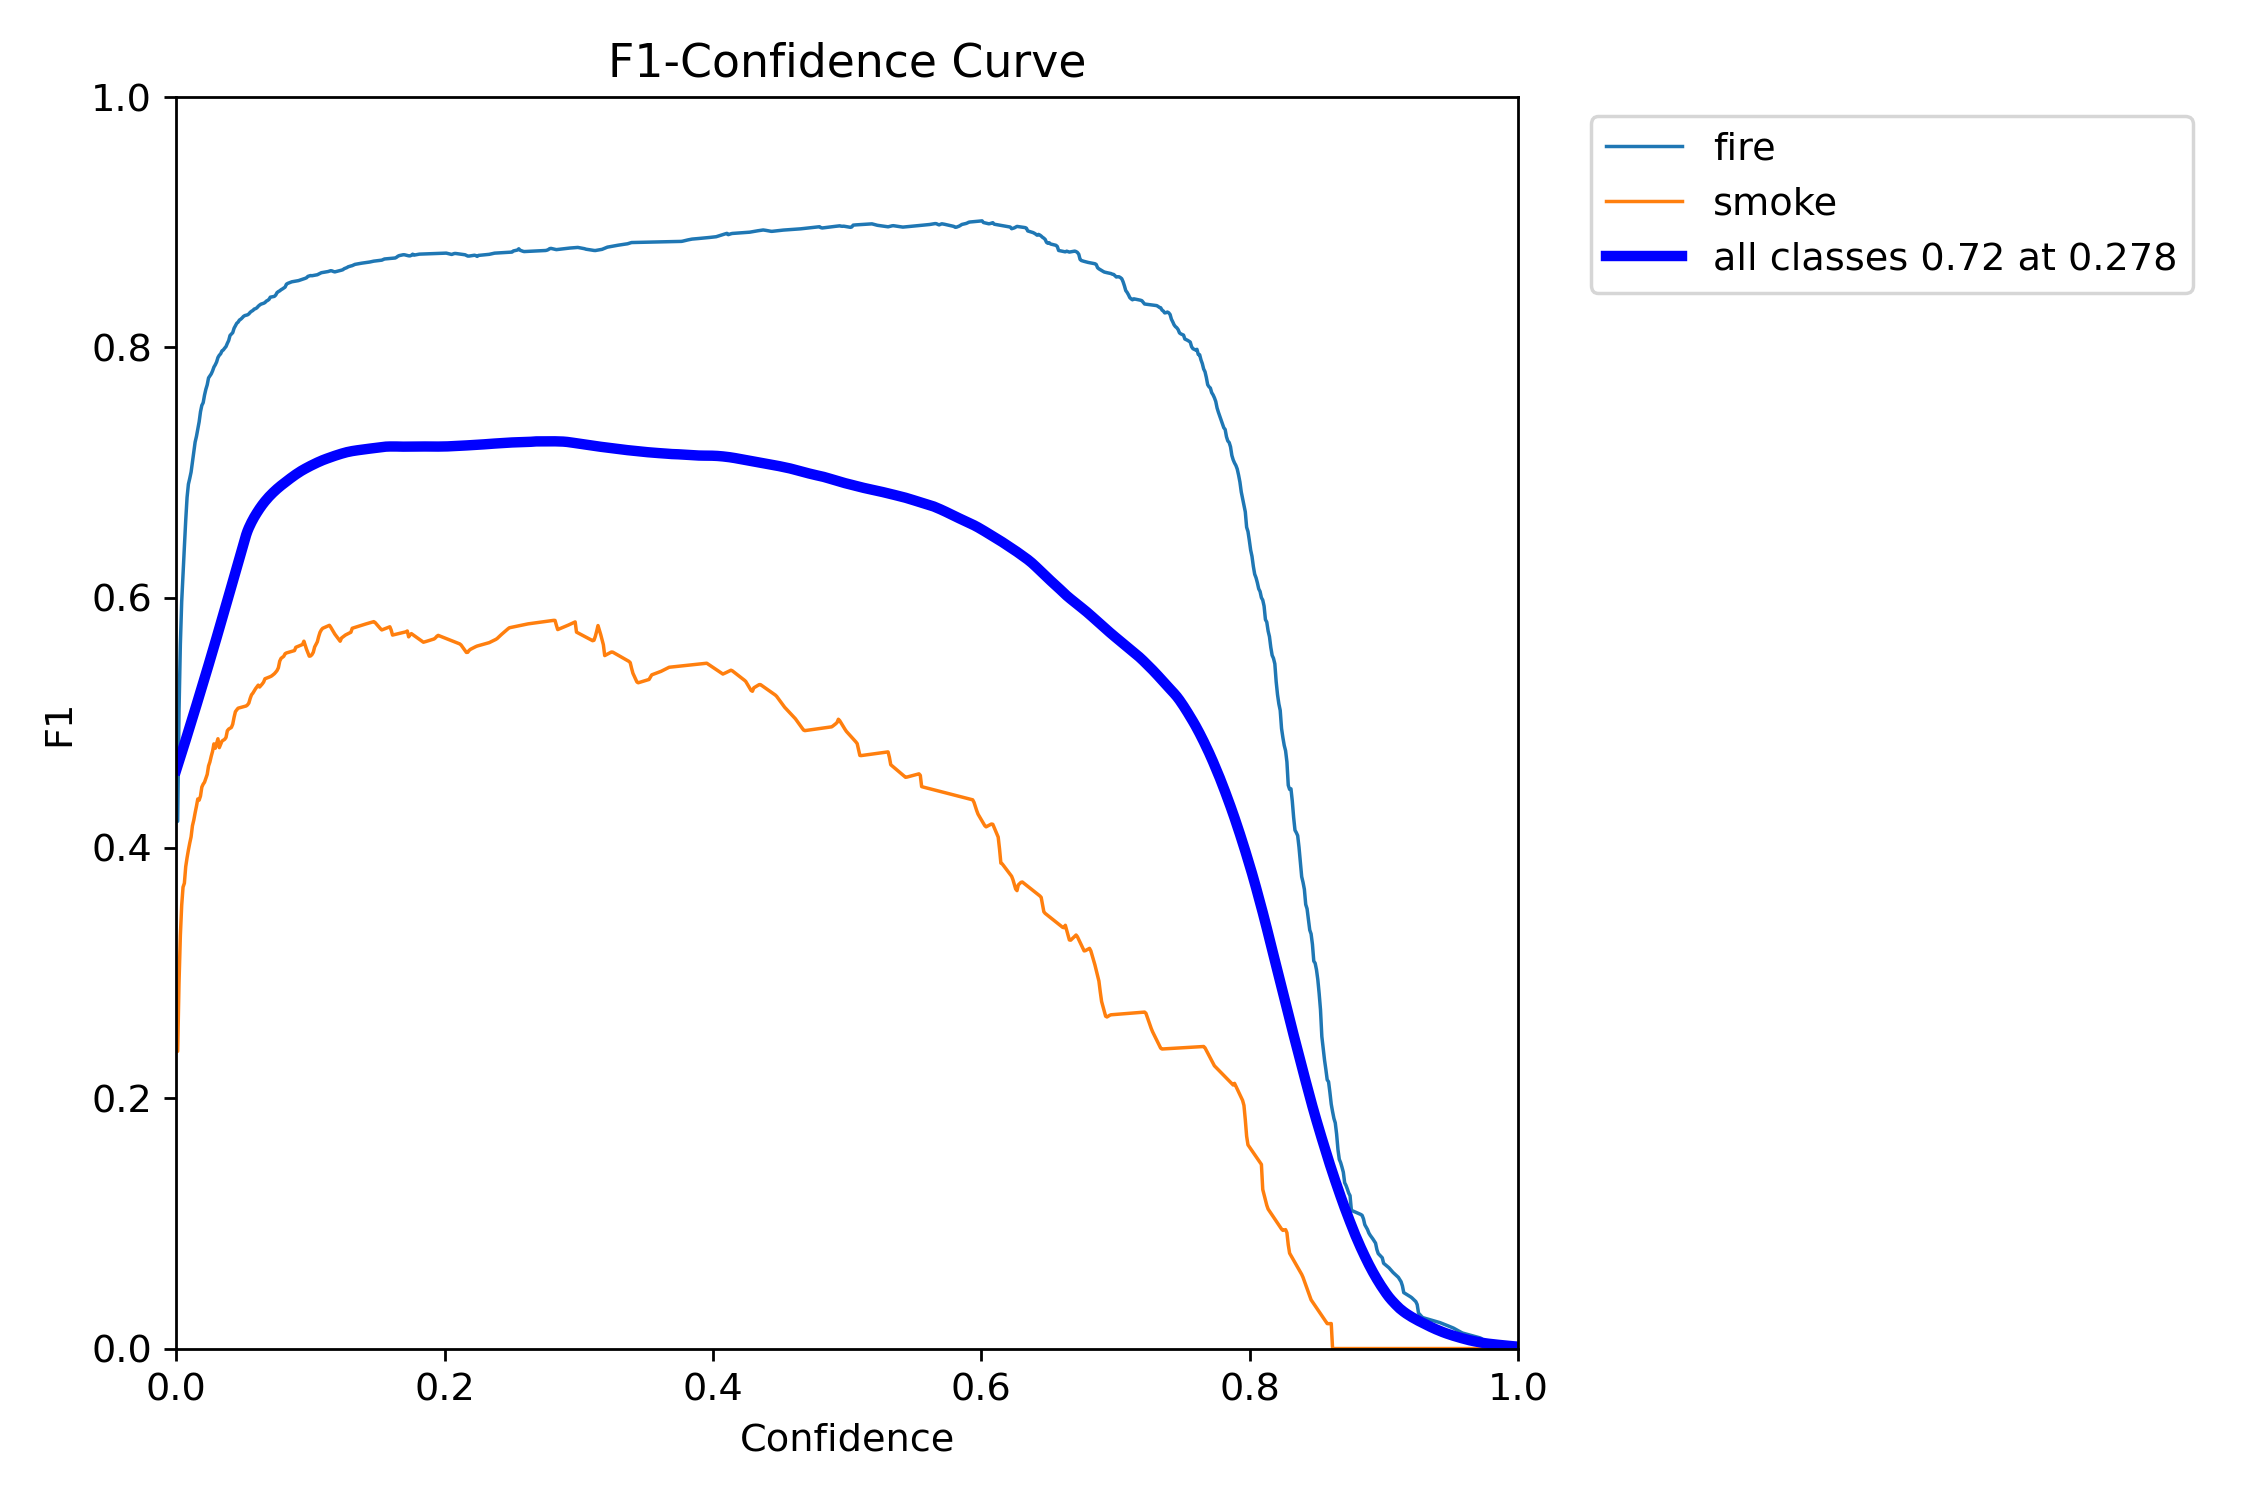

File: BoxPR_curve.png


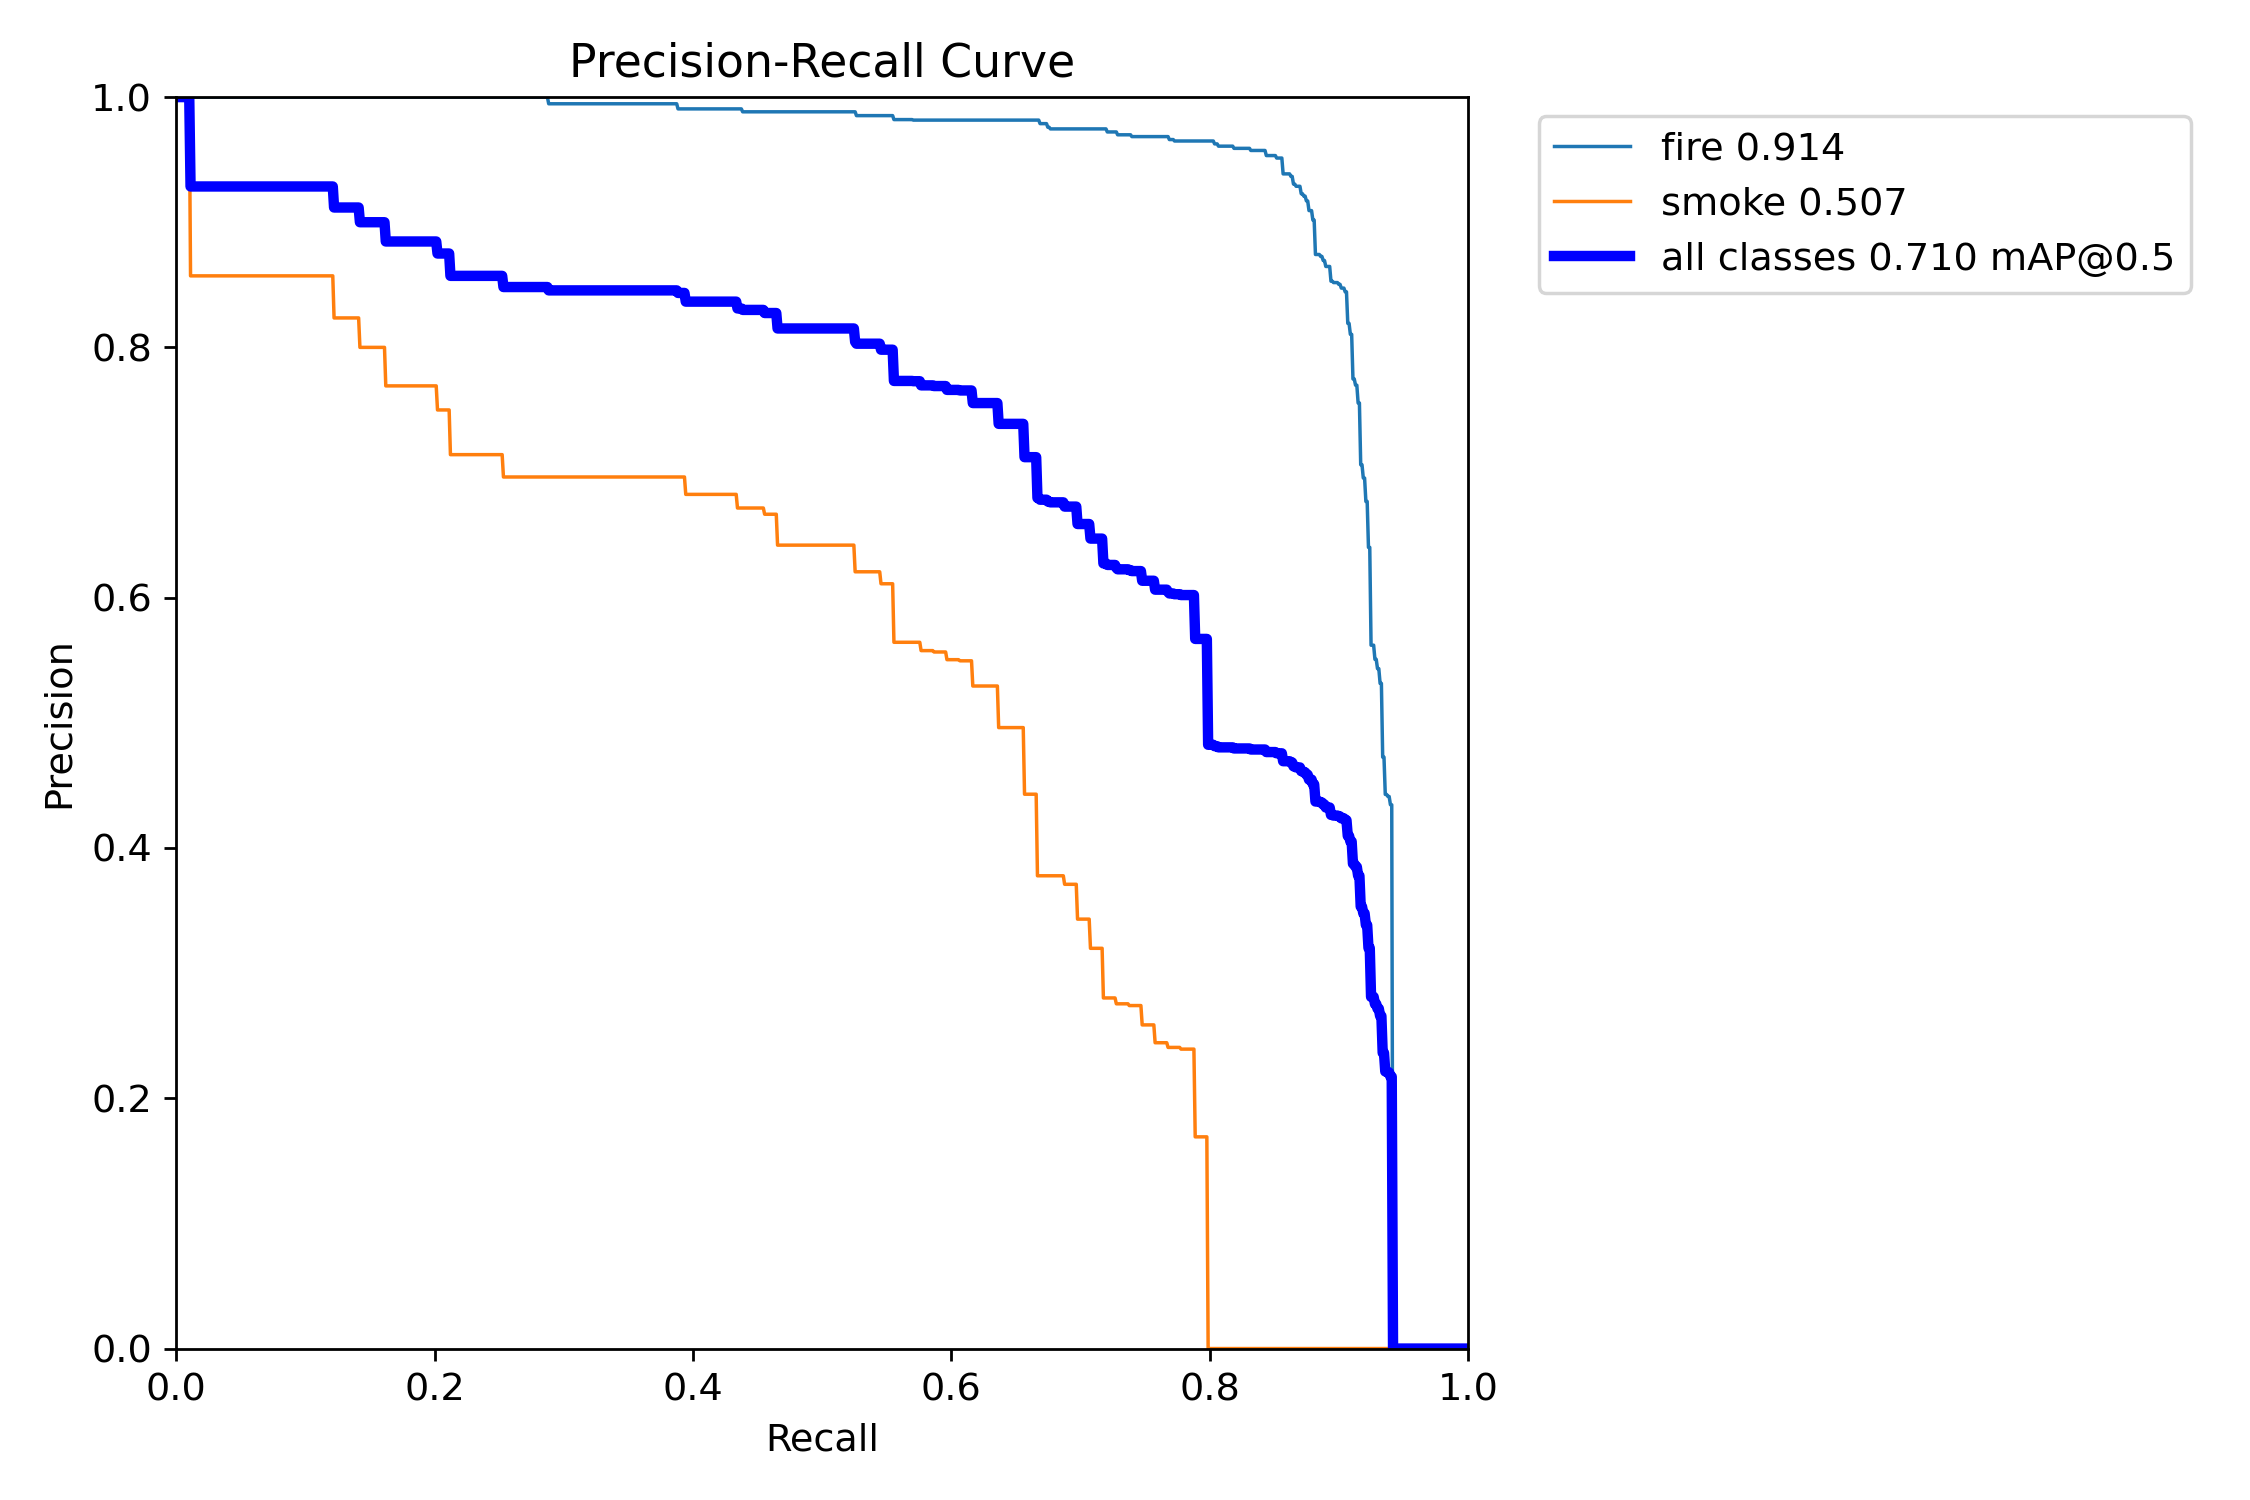

File: BoxP_curve.png


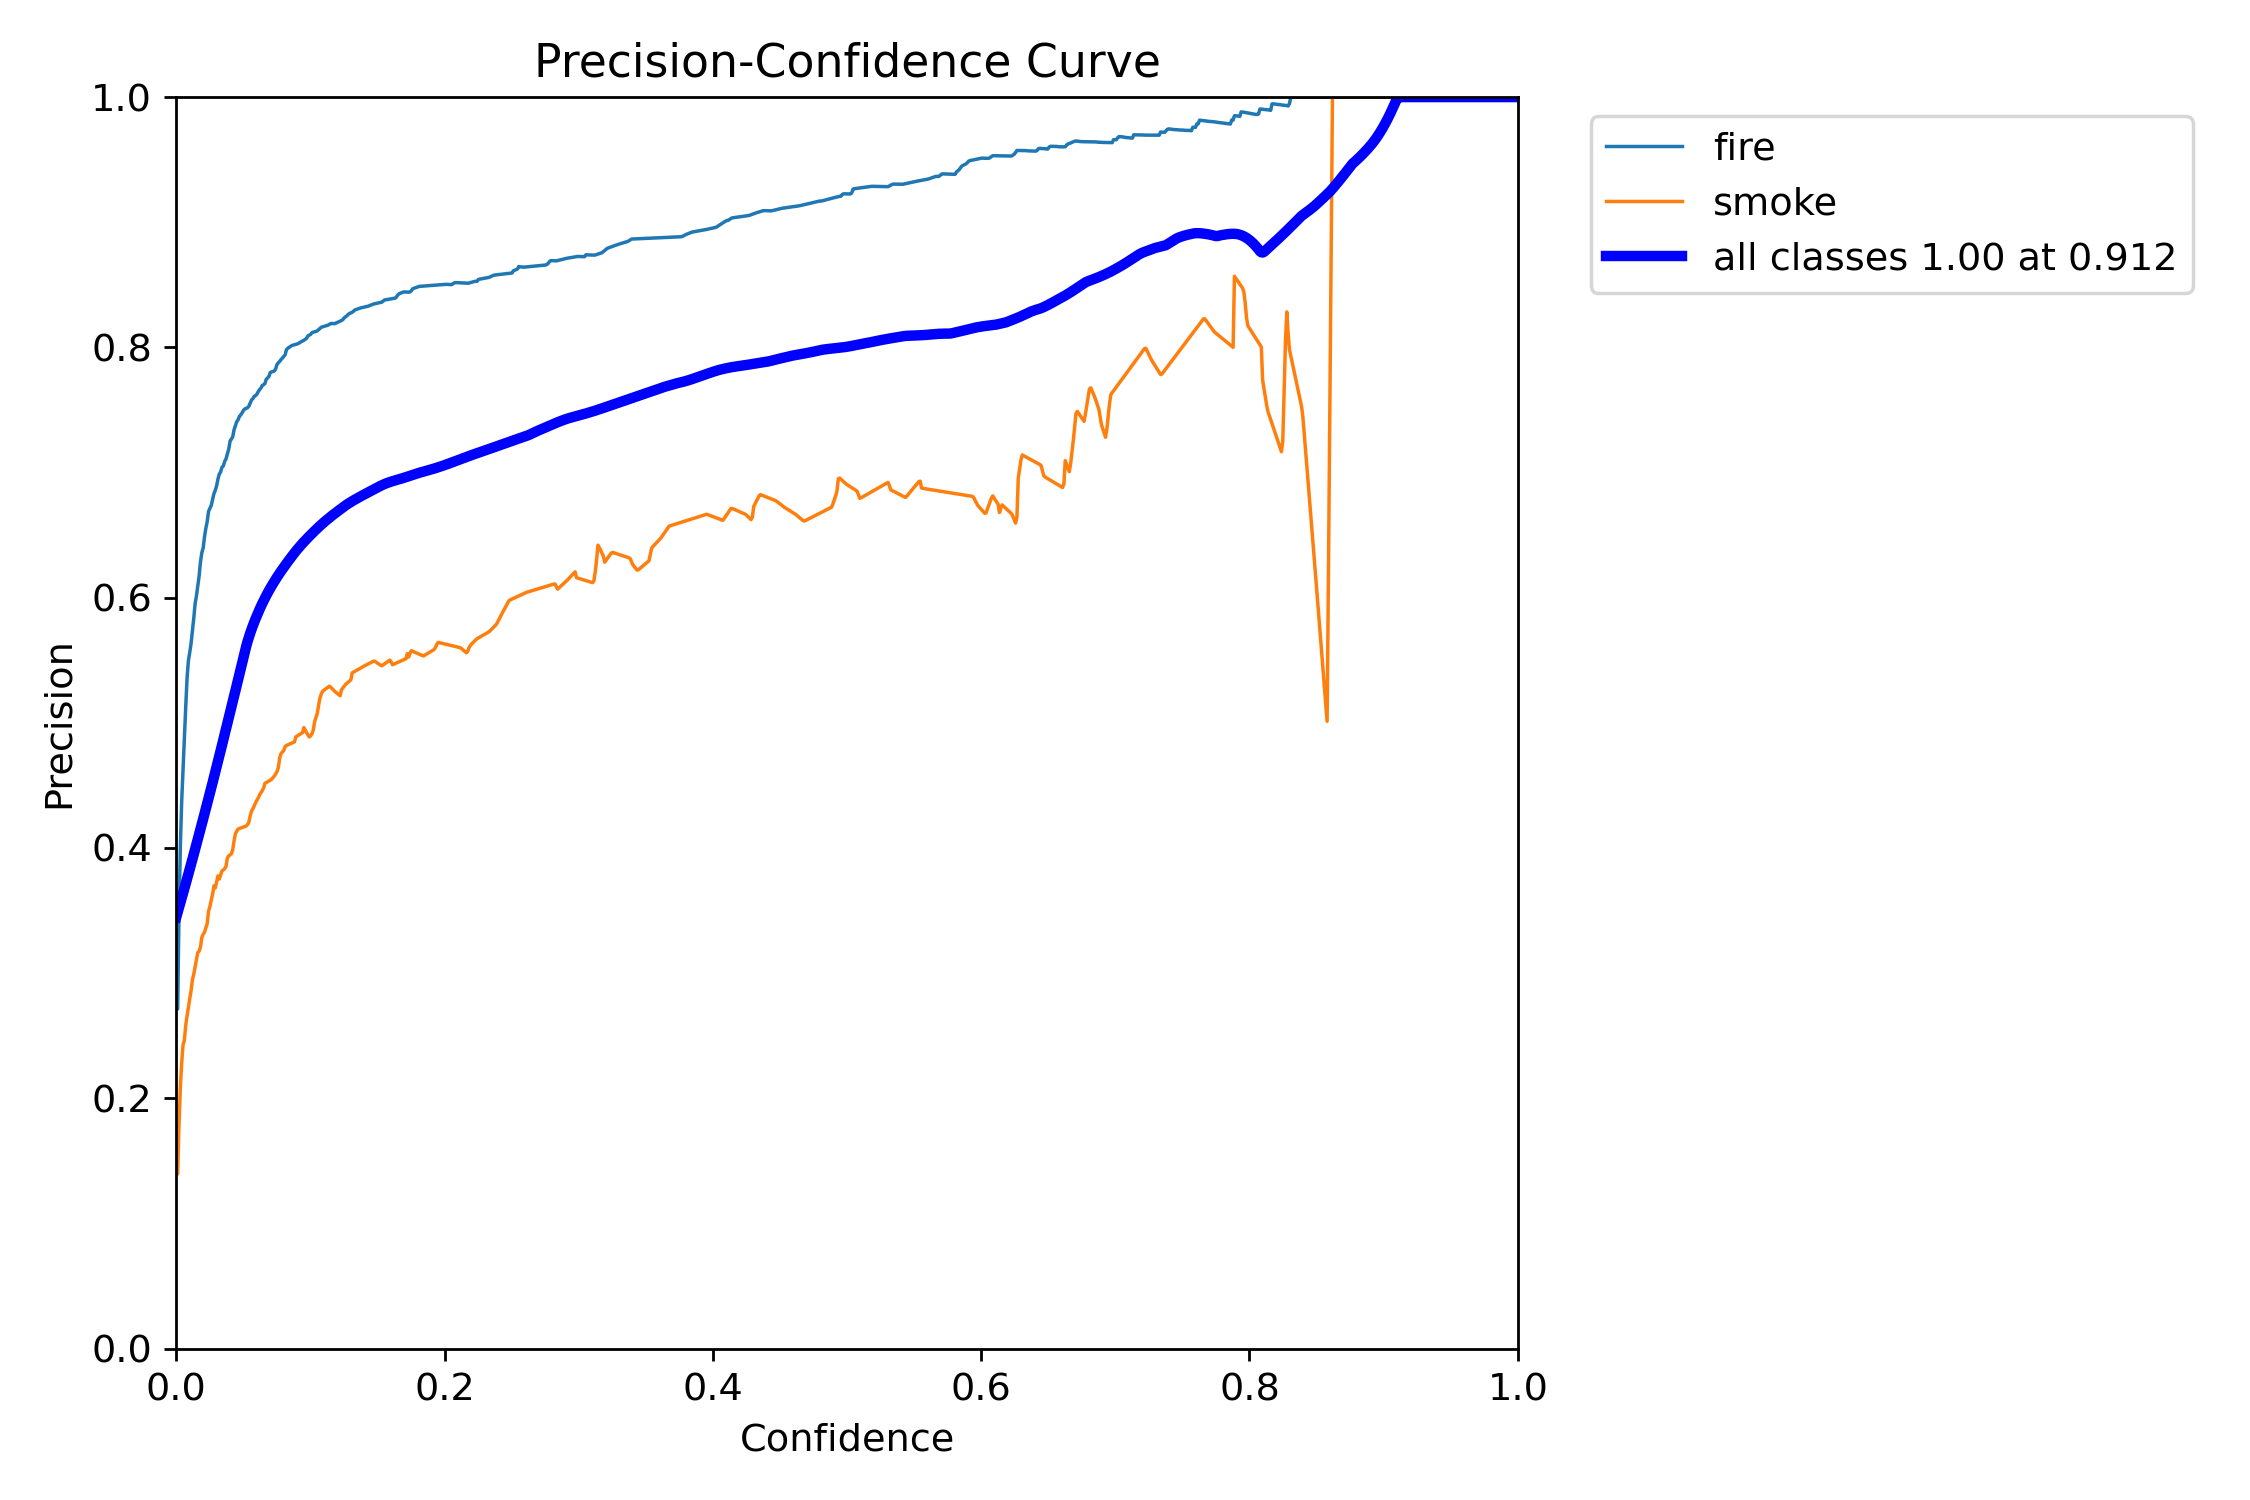

File: BoxR_curve.png


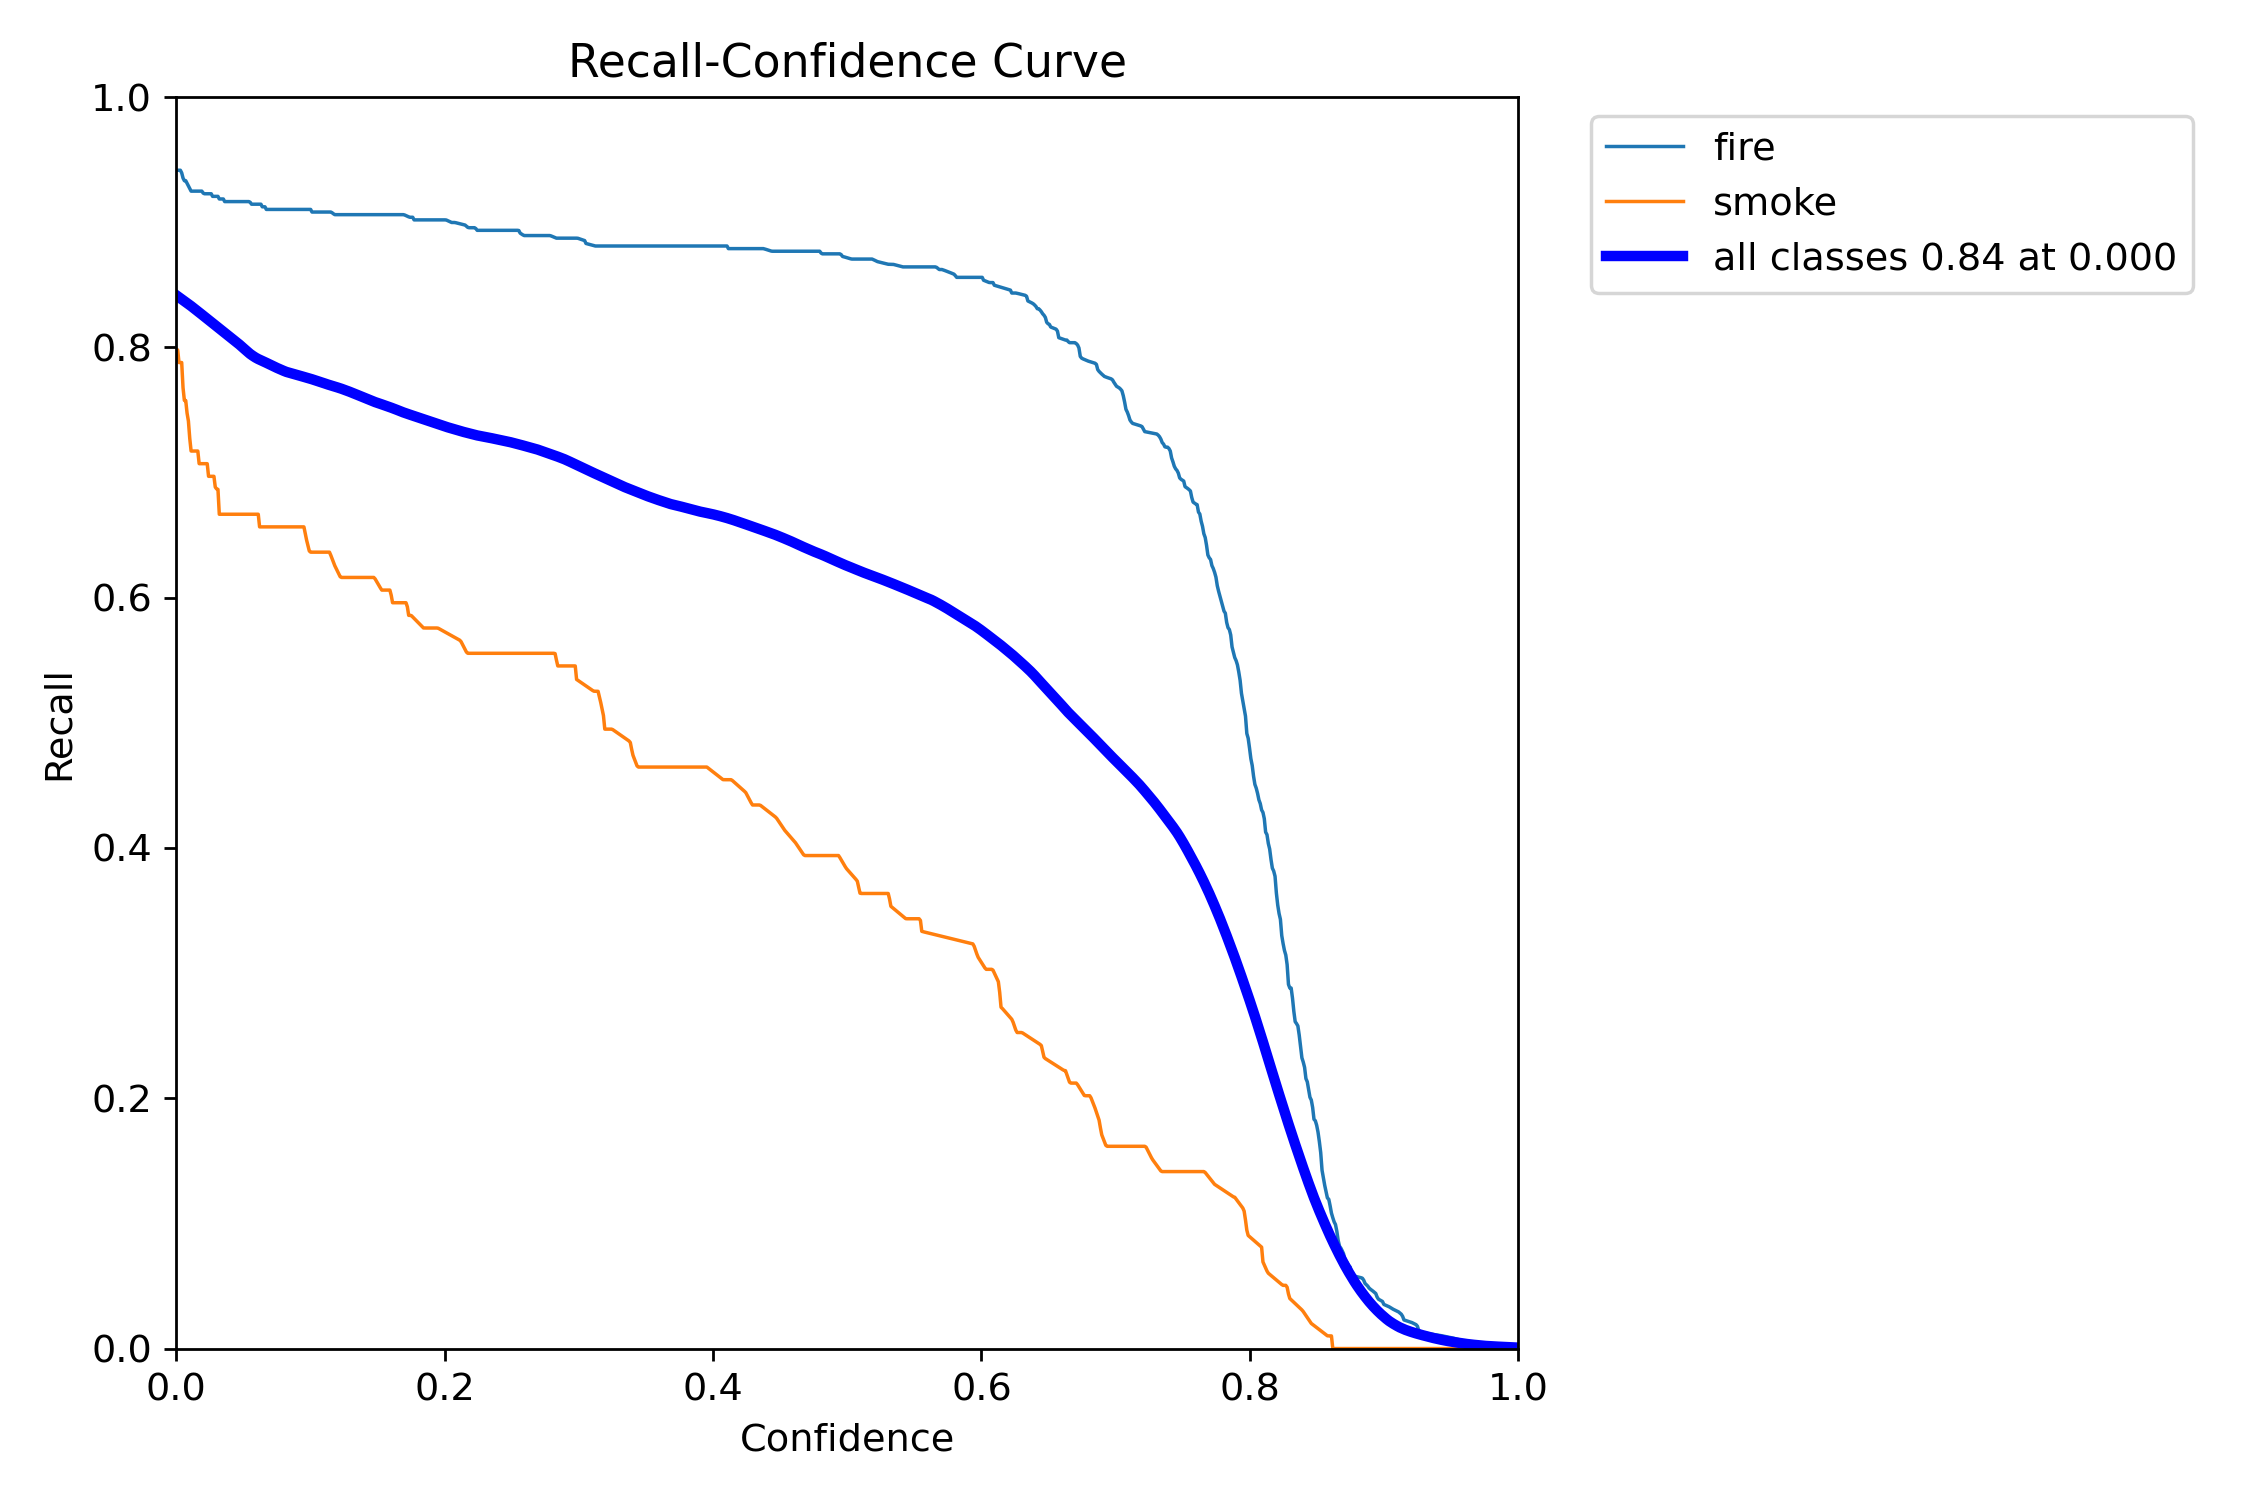

File: confusion_matrix.png


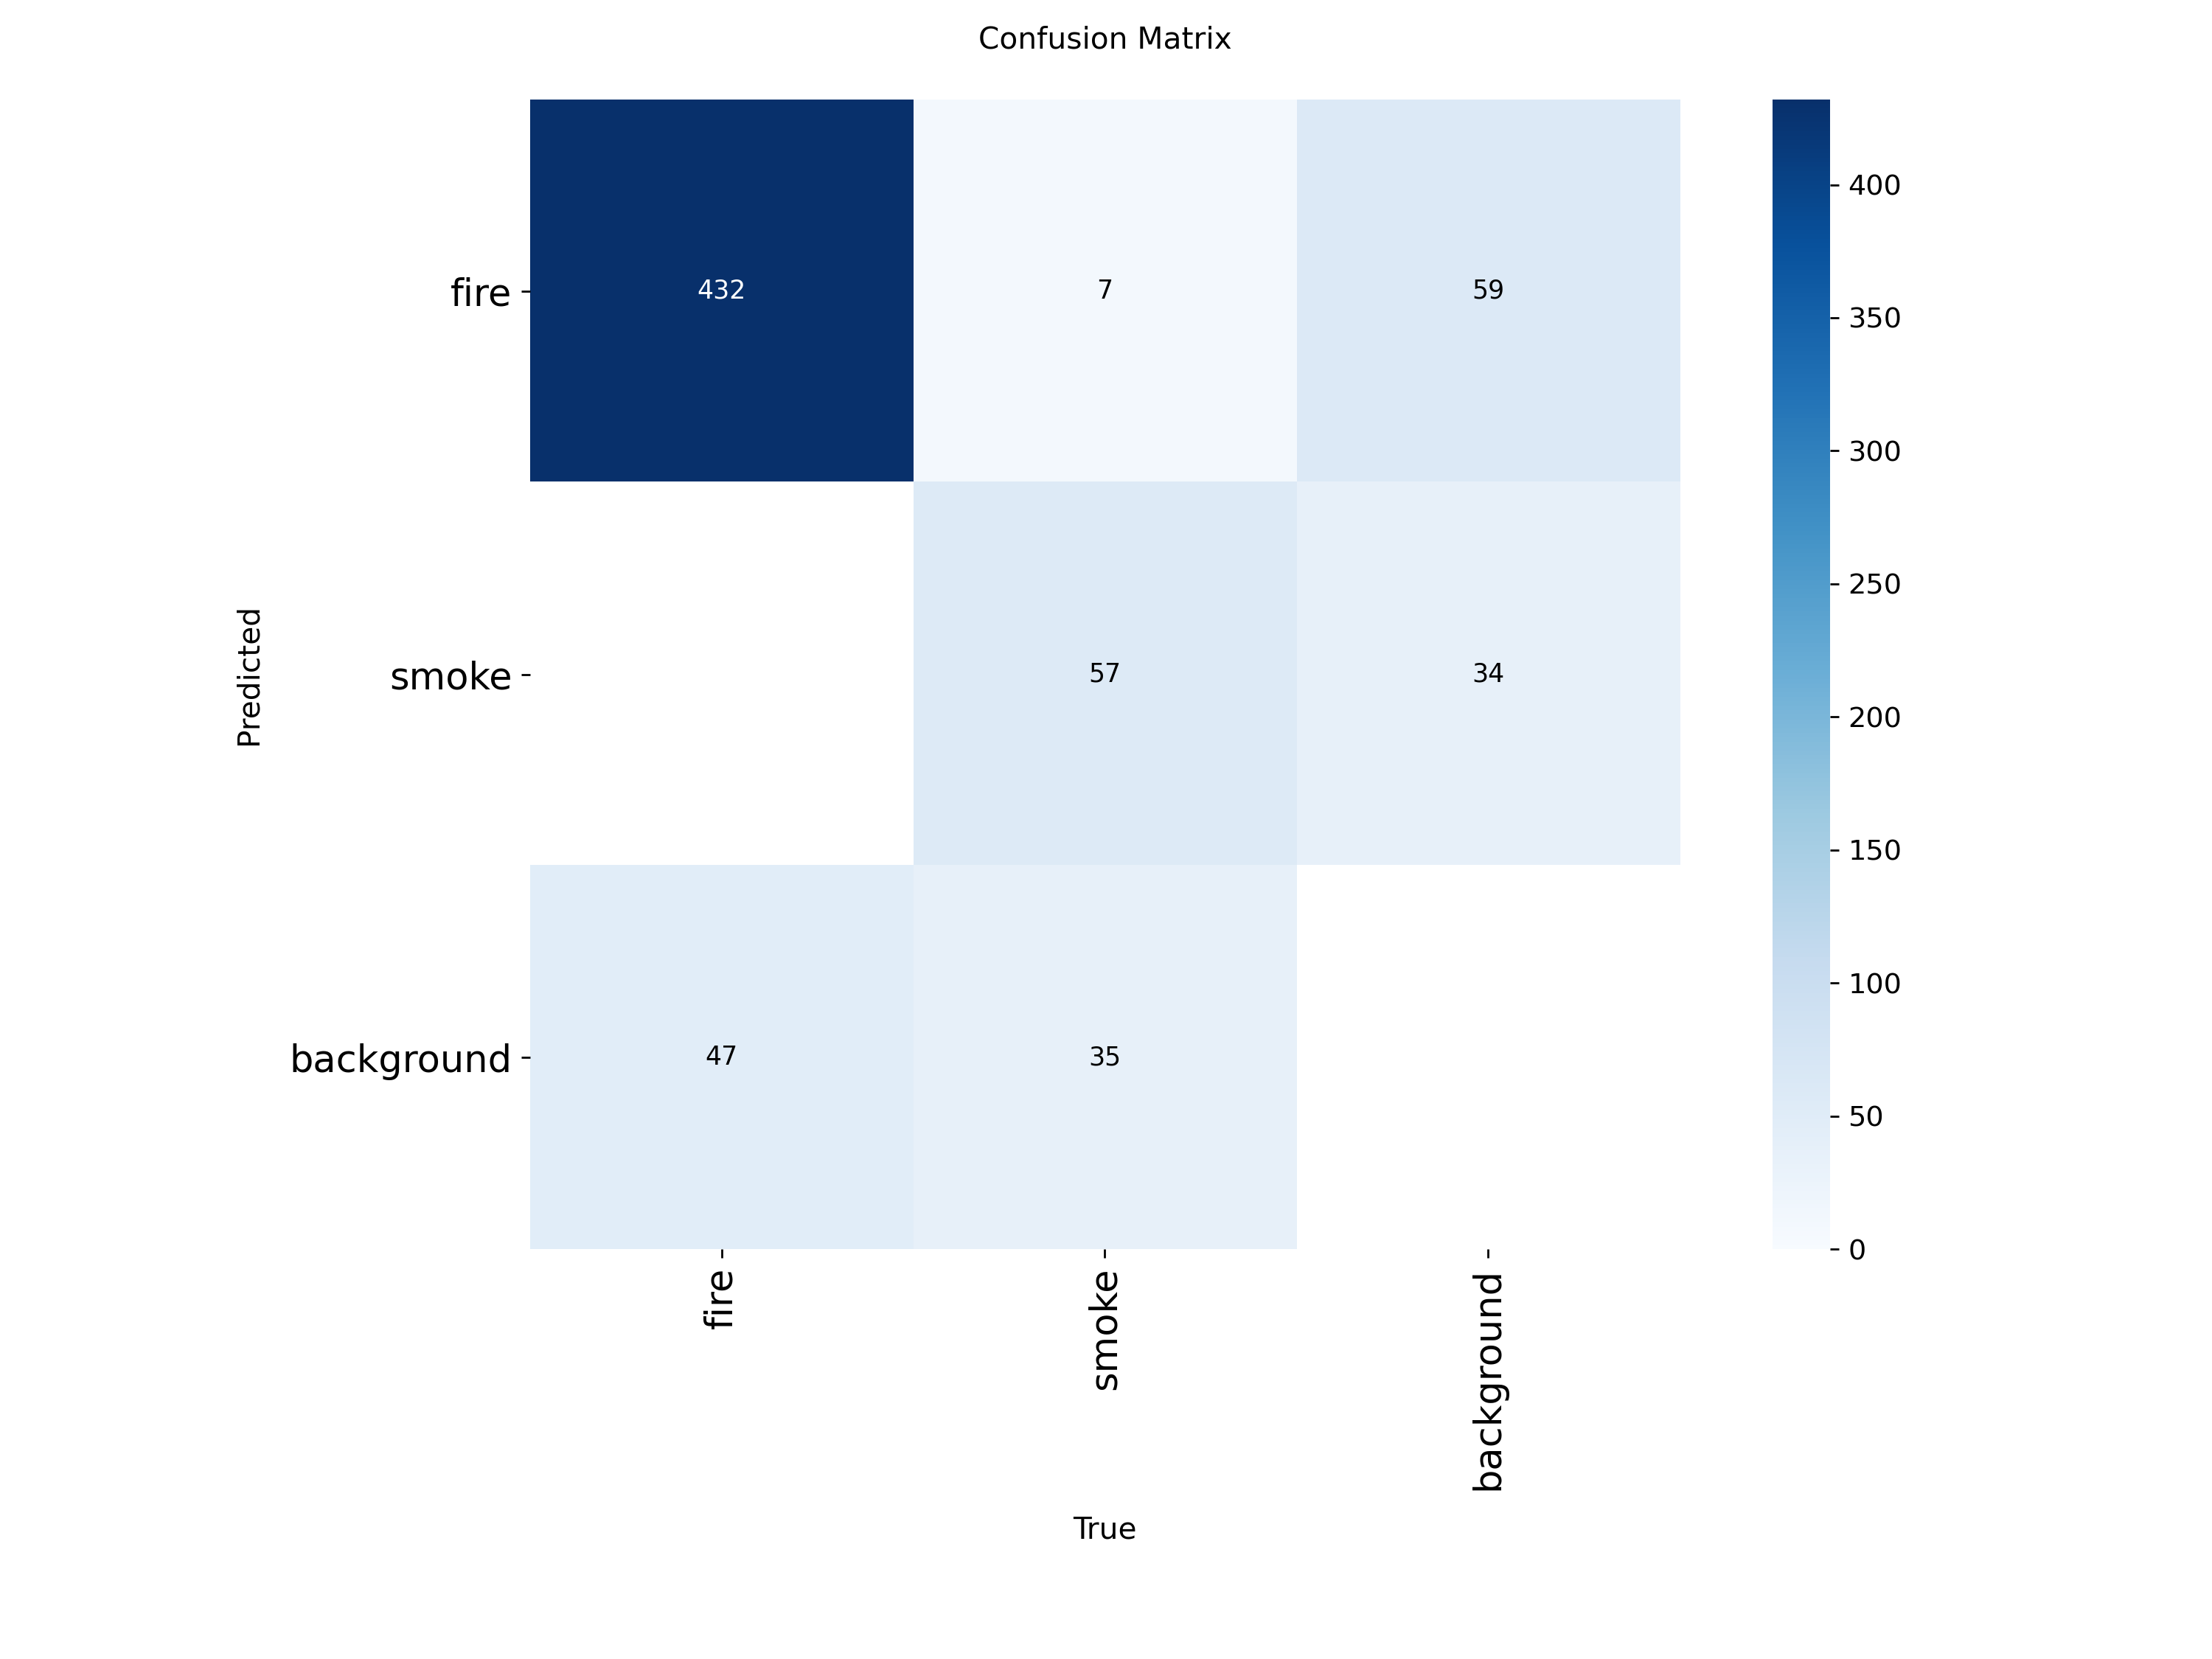

File: confusion_matrix_normalized.png


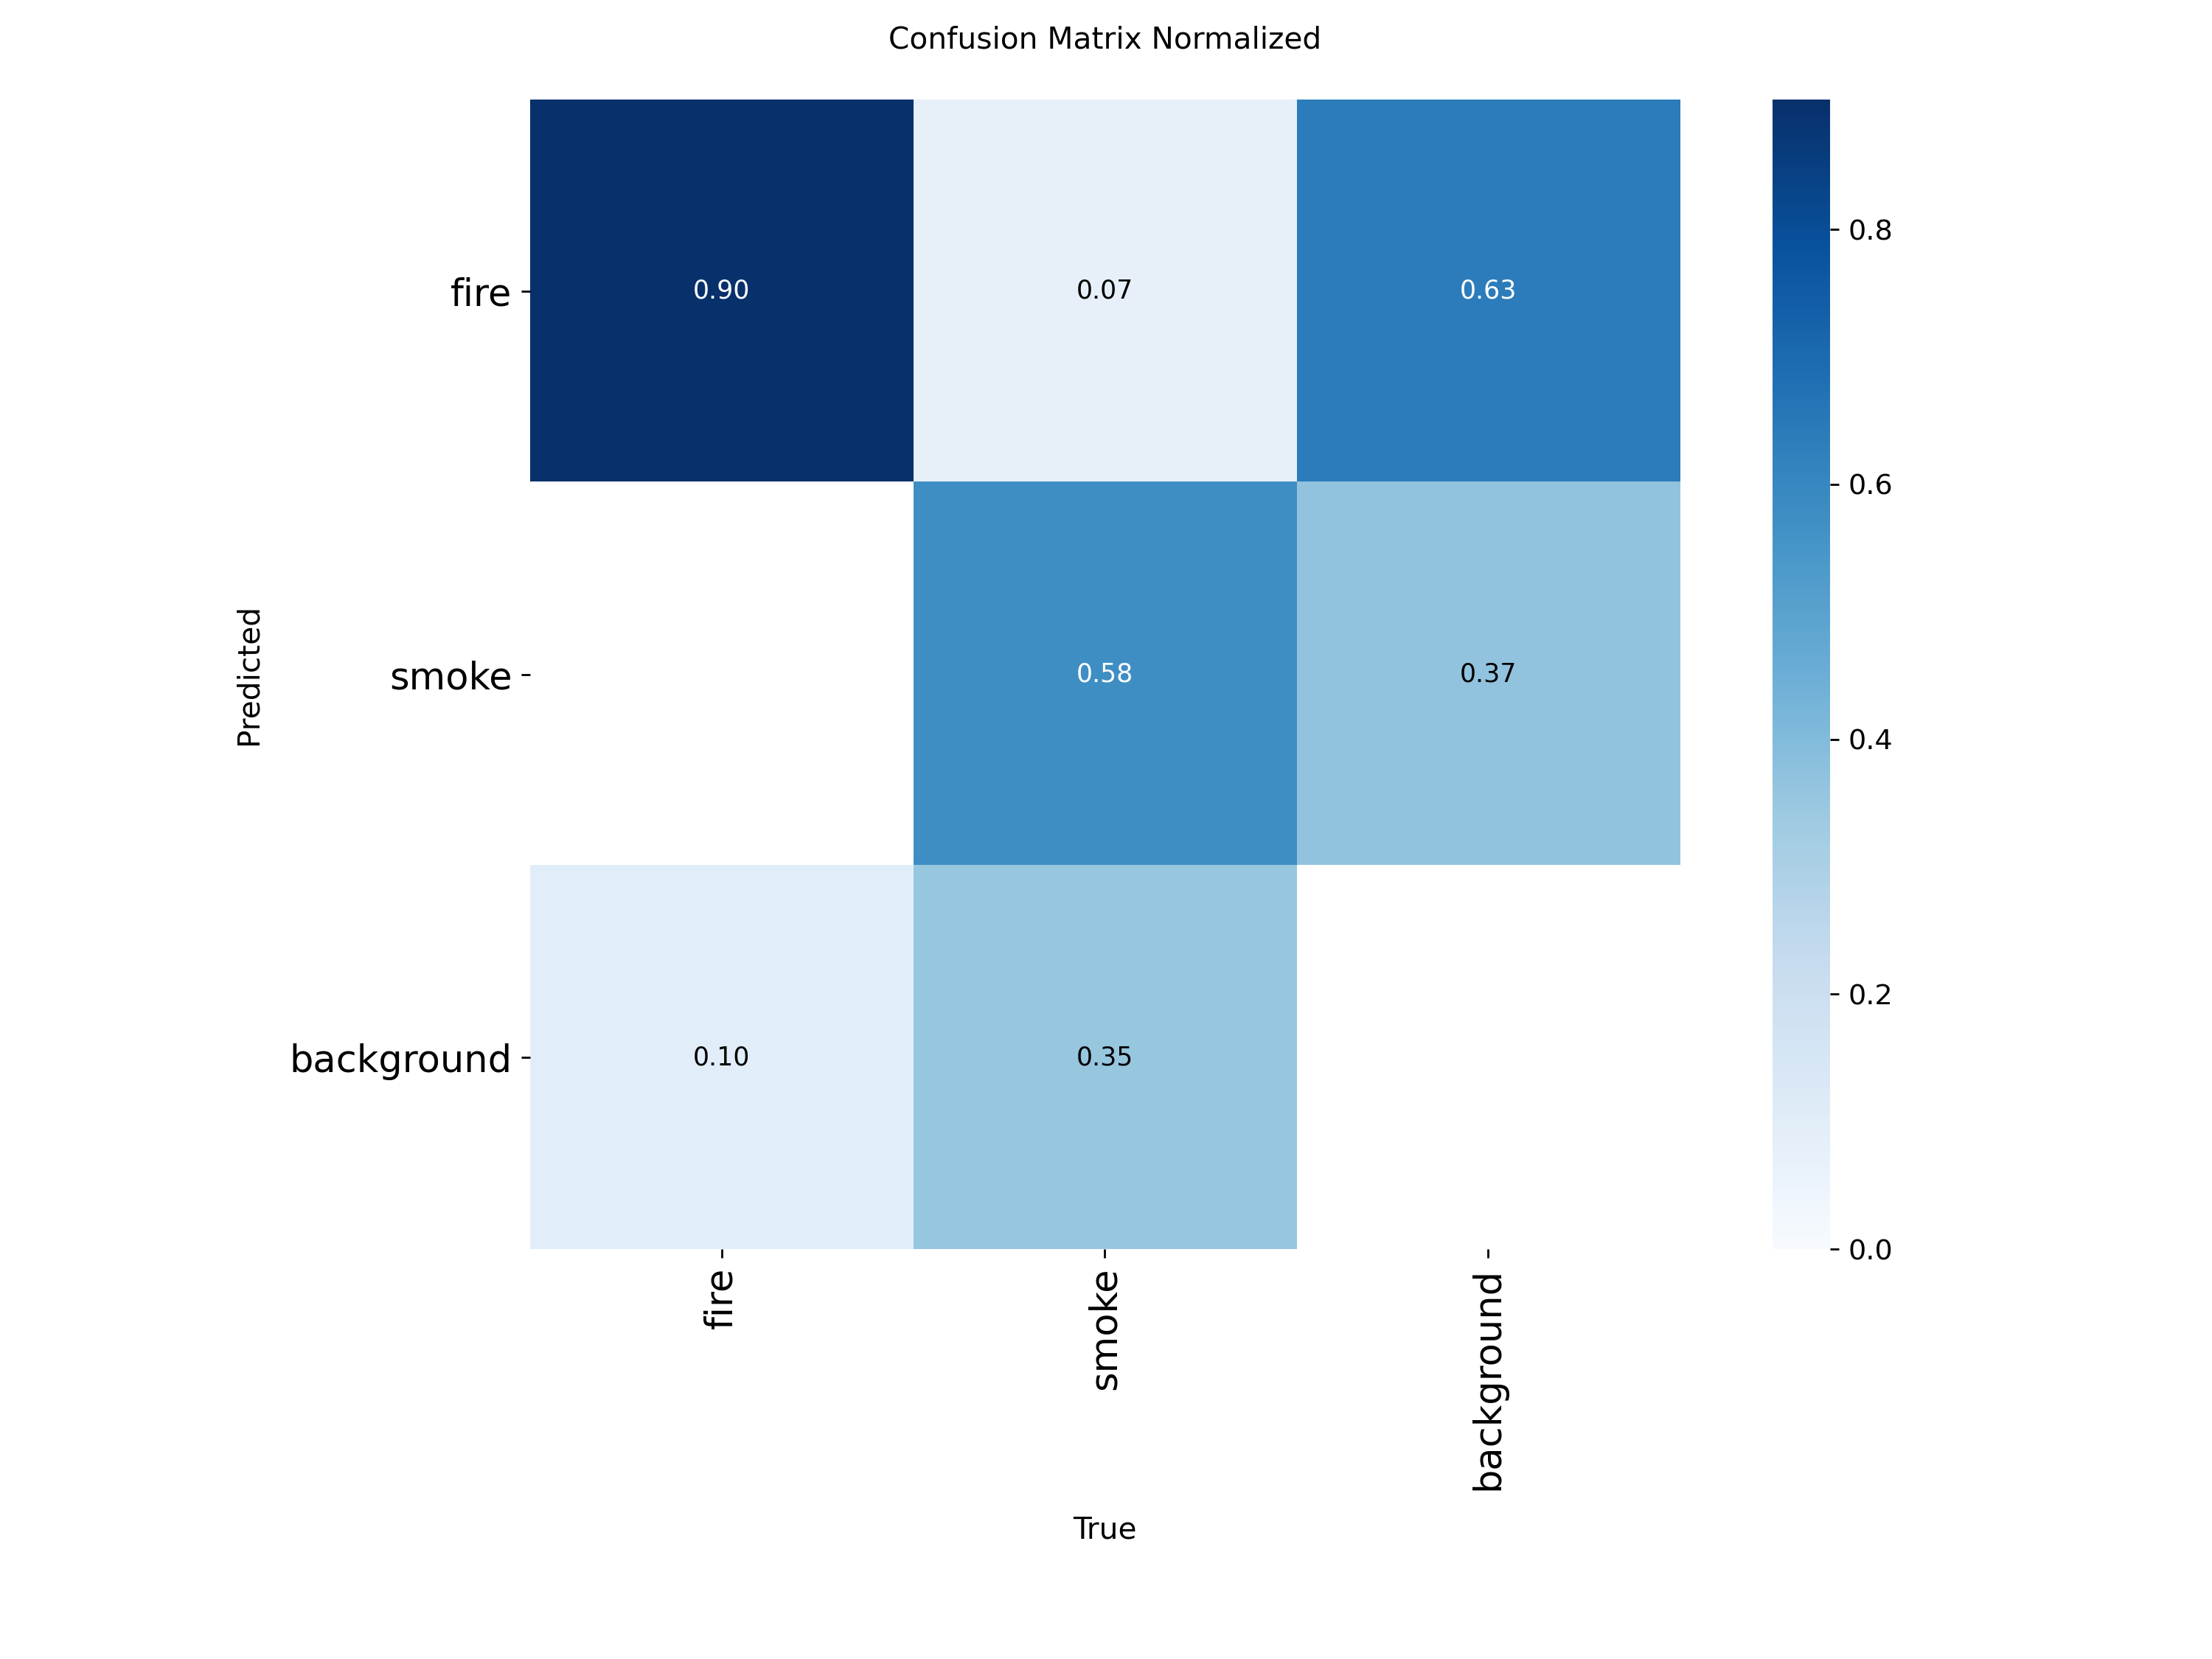

In [ ]:
import os
import glob
from IPython.display import Image, display

# البحث عن كل صور png داخل مجلد val
val_pngs = glob.glob('/content/runs/detect/val/*.png')

if val_pngs:
    for img_path in sorted(val_pngs):
        print(f"File: {os.path.basename(img_path)}")
        display(Image(filename=img_path))
else:
    print("المجلد فارغ من صور PNG، الملفات الموجودة حالياً داخل val هي:")
    print(os.listdir('/content/runs/detect/val'))

## 9 · Training run 2 — 50 epochs, AdamW

A second attempt to improve on run 1, changing four things at once: more epochs,
the AdamW optimiser, a lower learning rate, and reduced mosaic augmentation with
`close_mosaic` so the last 10 epochs train on unaugmented images.

The reasoning was that lighter mosaic would help the model learn faint smoke,
which run 1 handled poorly.

Settings: `epochs=50`, `imgsz=640`, `batch=16`, `lr0=0.001`, `optimizer='AdamW'`,
`mosaic=0.5`, `close_mosaic=10`.

Weights are saved as `run2_v2_50ep.pt`. The comparison against run 1 is made on
the held-out test split in notebook 02.

In [ ]:
from ultralytics import YOLO

# 1. تحميل النموذج الأساسي النظيف
model = YOLO('yolo11n.pt')

# 2. بدء التدريب مع تعديل معامل Mosaic والإعدادات
results = model.train(
    data='/content/Fire--smoke-Detection-1/data.yaml',
    epochs=50,           # 50 حقبة كافية جداً للوصول لدقة عالية
    imgsz=640,
    batch=16,
    lr0=0.001,           # معدل تعلم مستقر
    optimizer='AdamW',
    mosaic=0.5,          # تقليل الموزاييك للتعرف على الدخان الخفيف
    close_mosaic=10,     # إيقاف الموزاييك في آخر 10 حقب لضبط الحواف
    name='fire_smoke_v2'
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fire--smoke-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=fire_smoke_v2, nbs

## 10 · Run 2 — training curves and confusion matrix

📊 confusion_matrix.png:


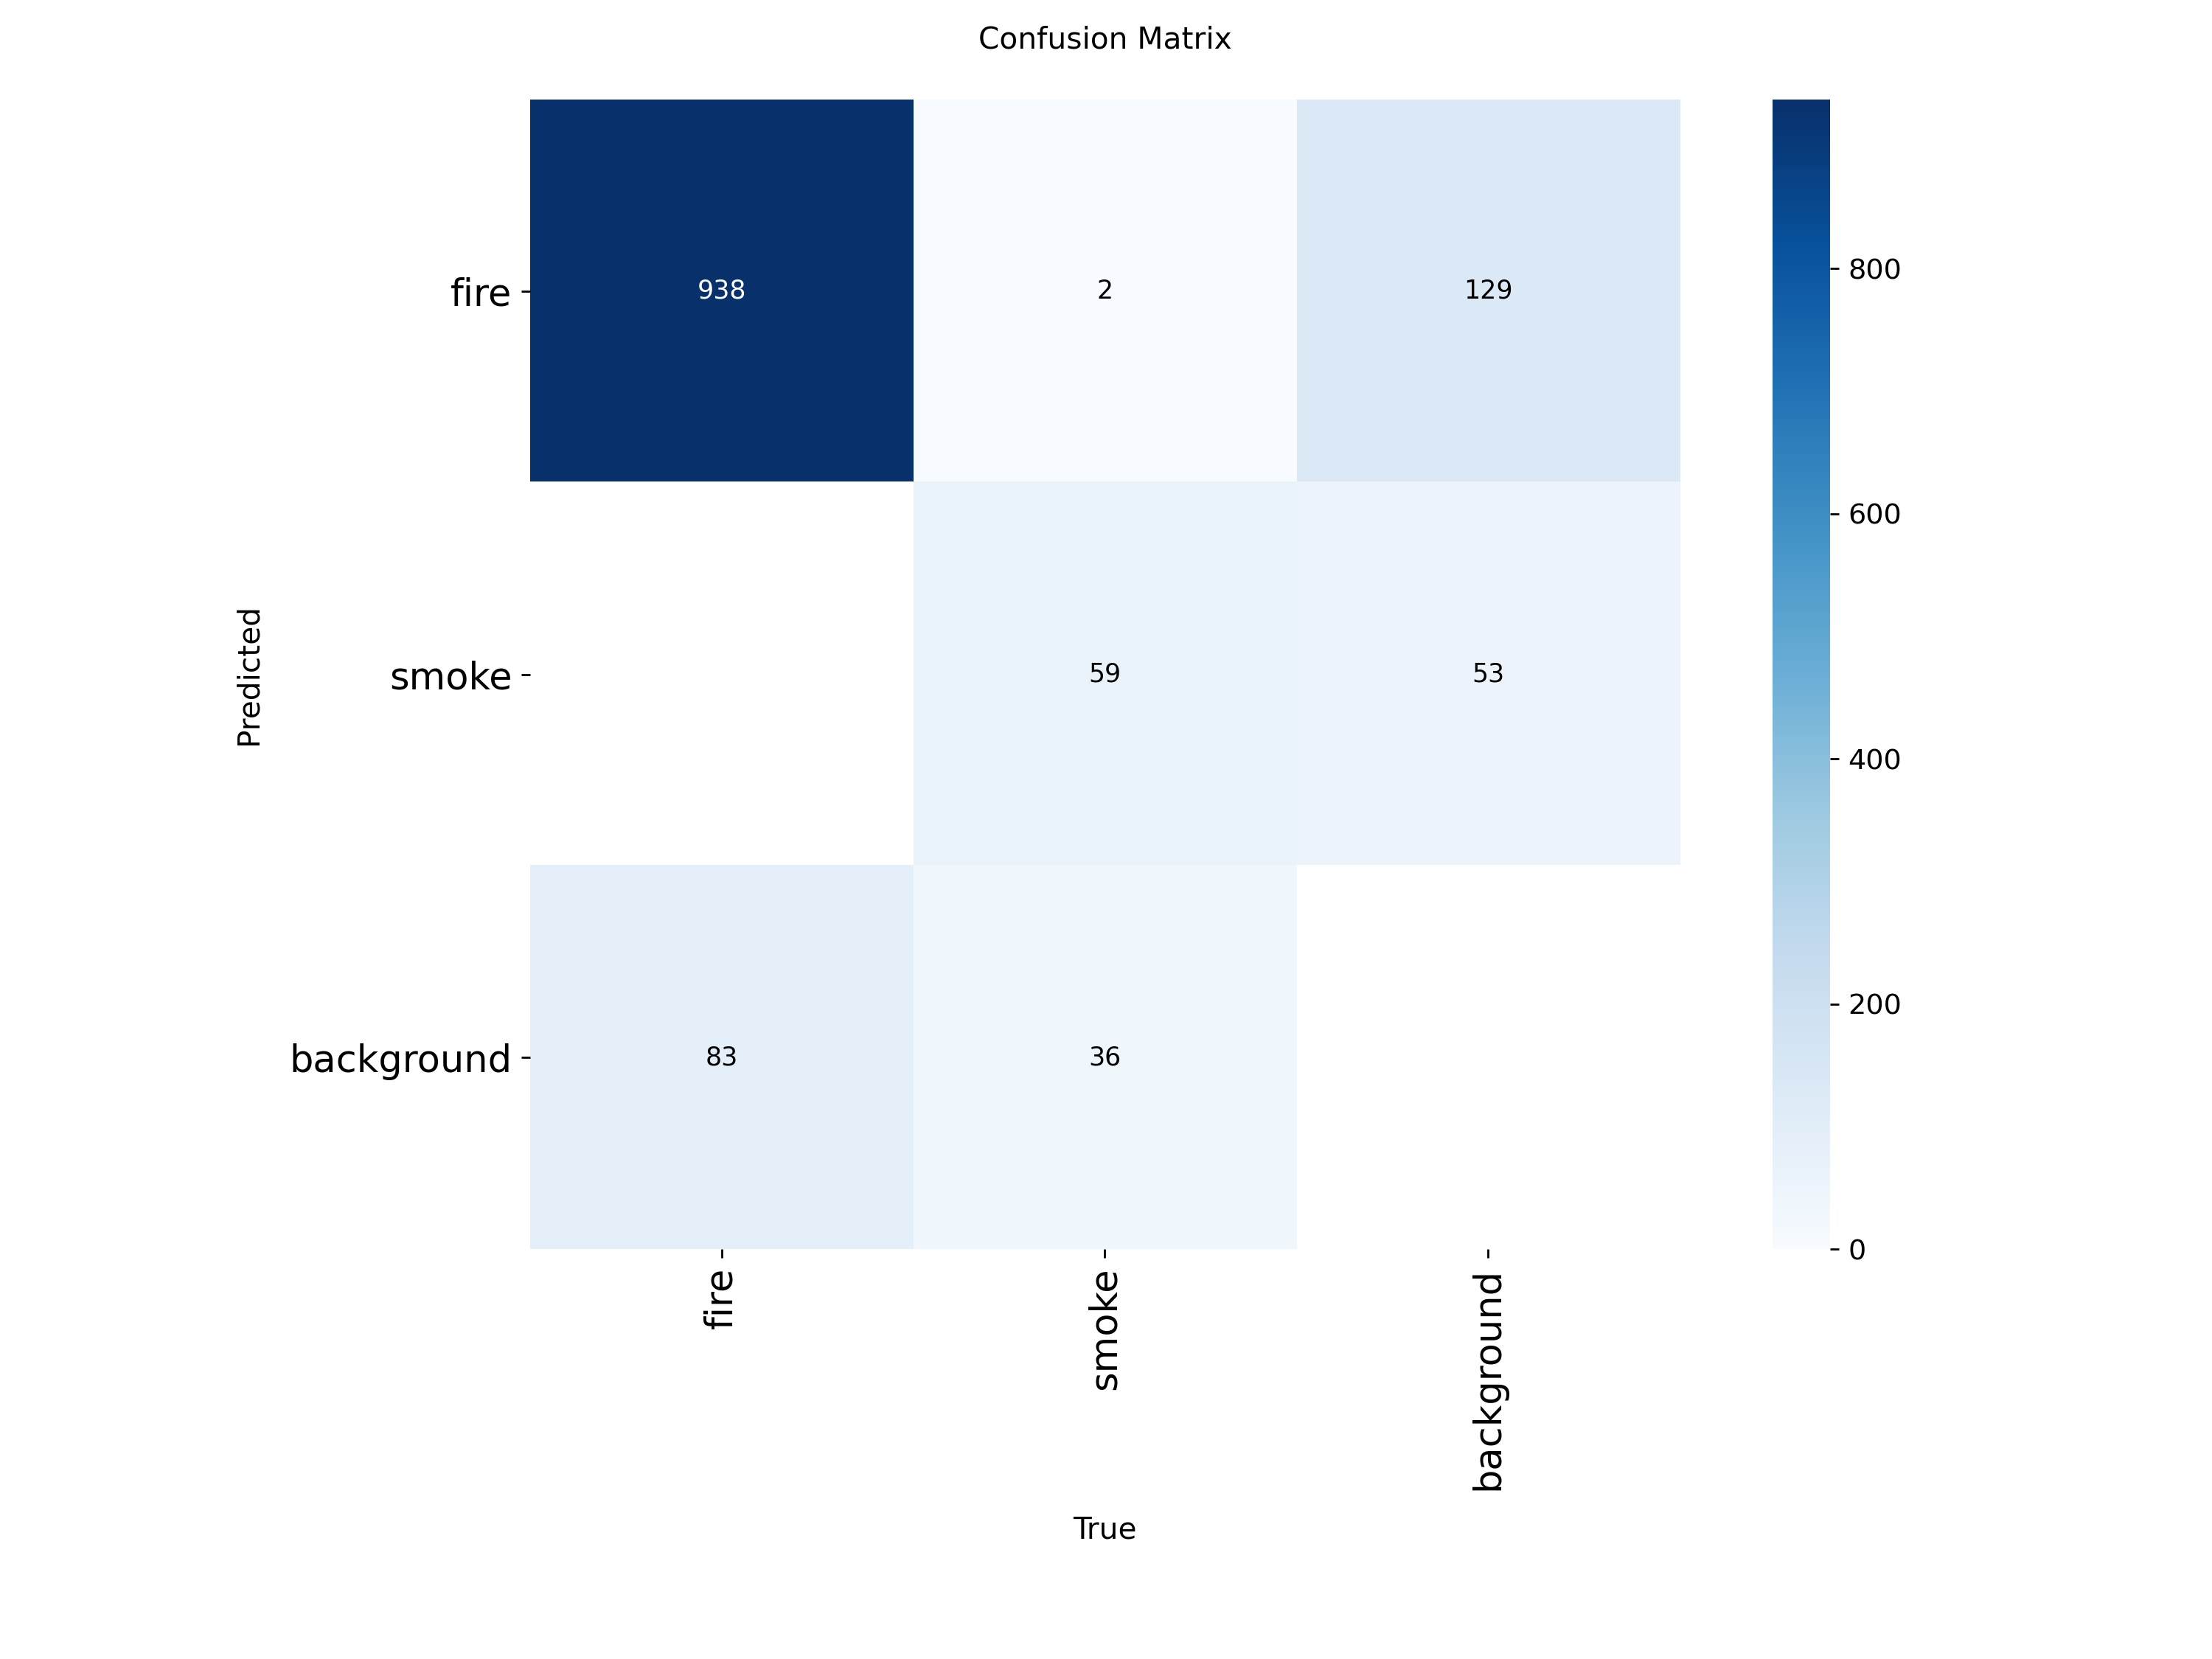

--------------------------------------------------
📊 confusion_matrix_normalized.png:


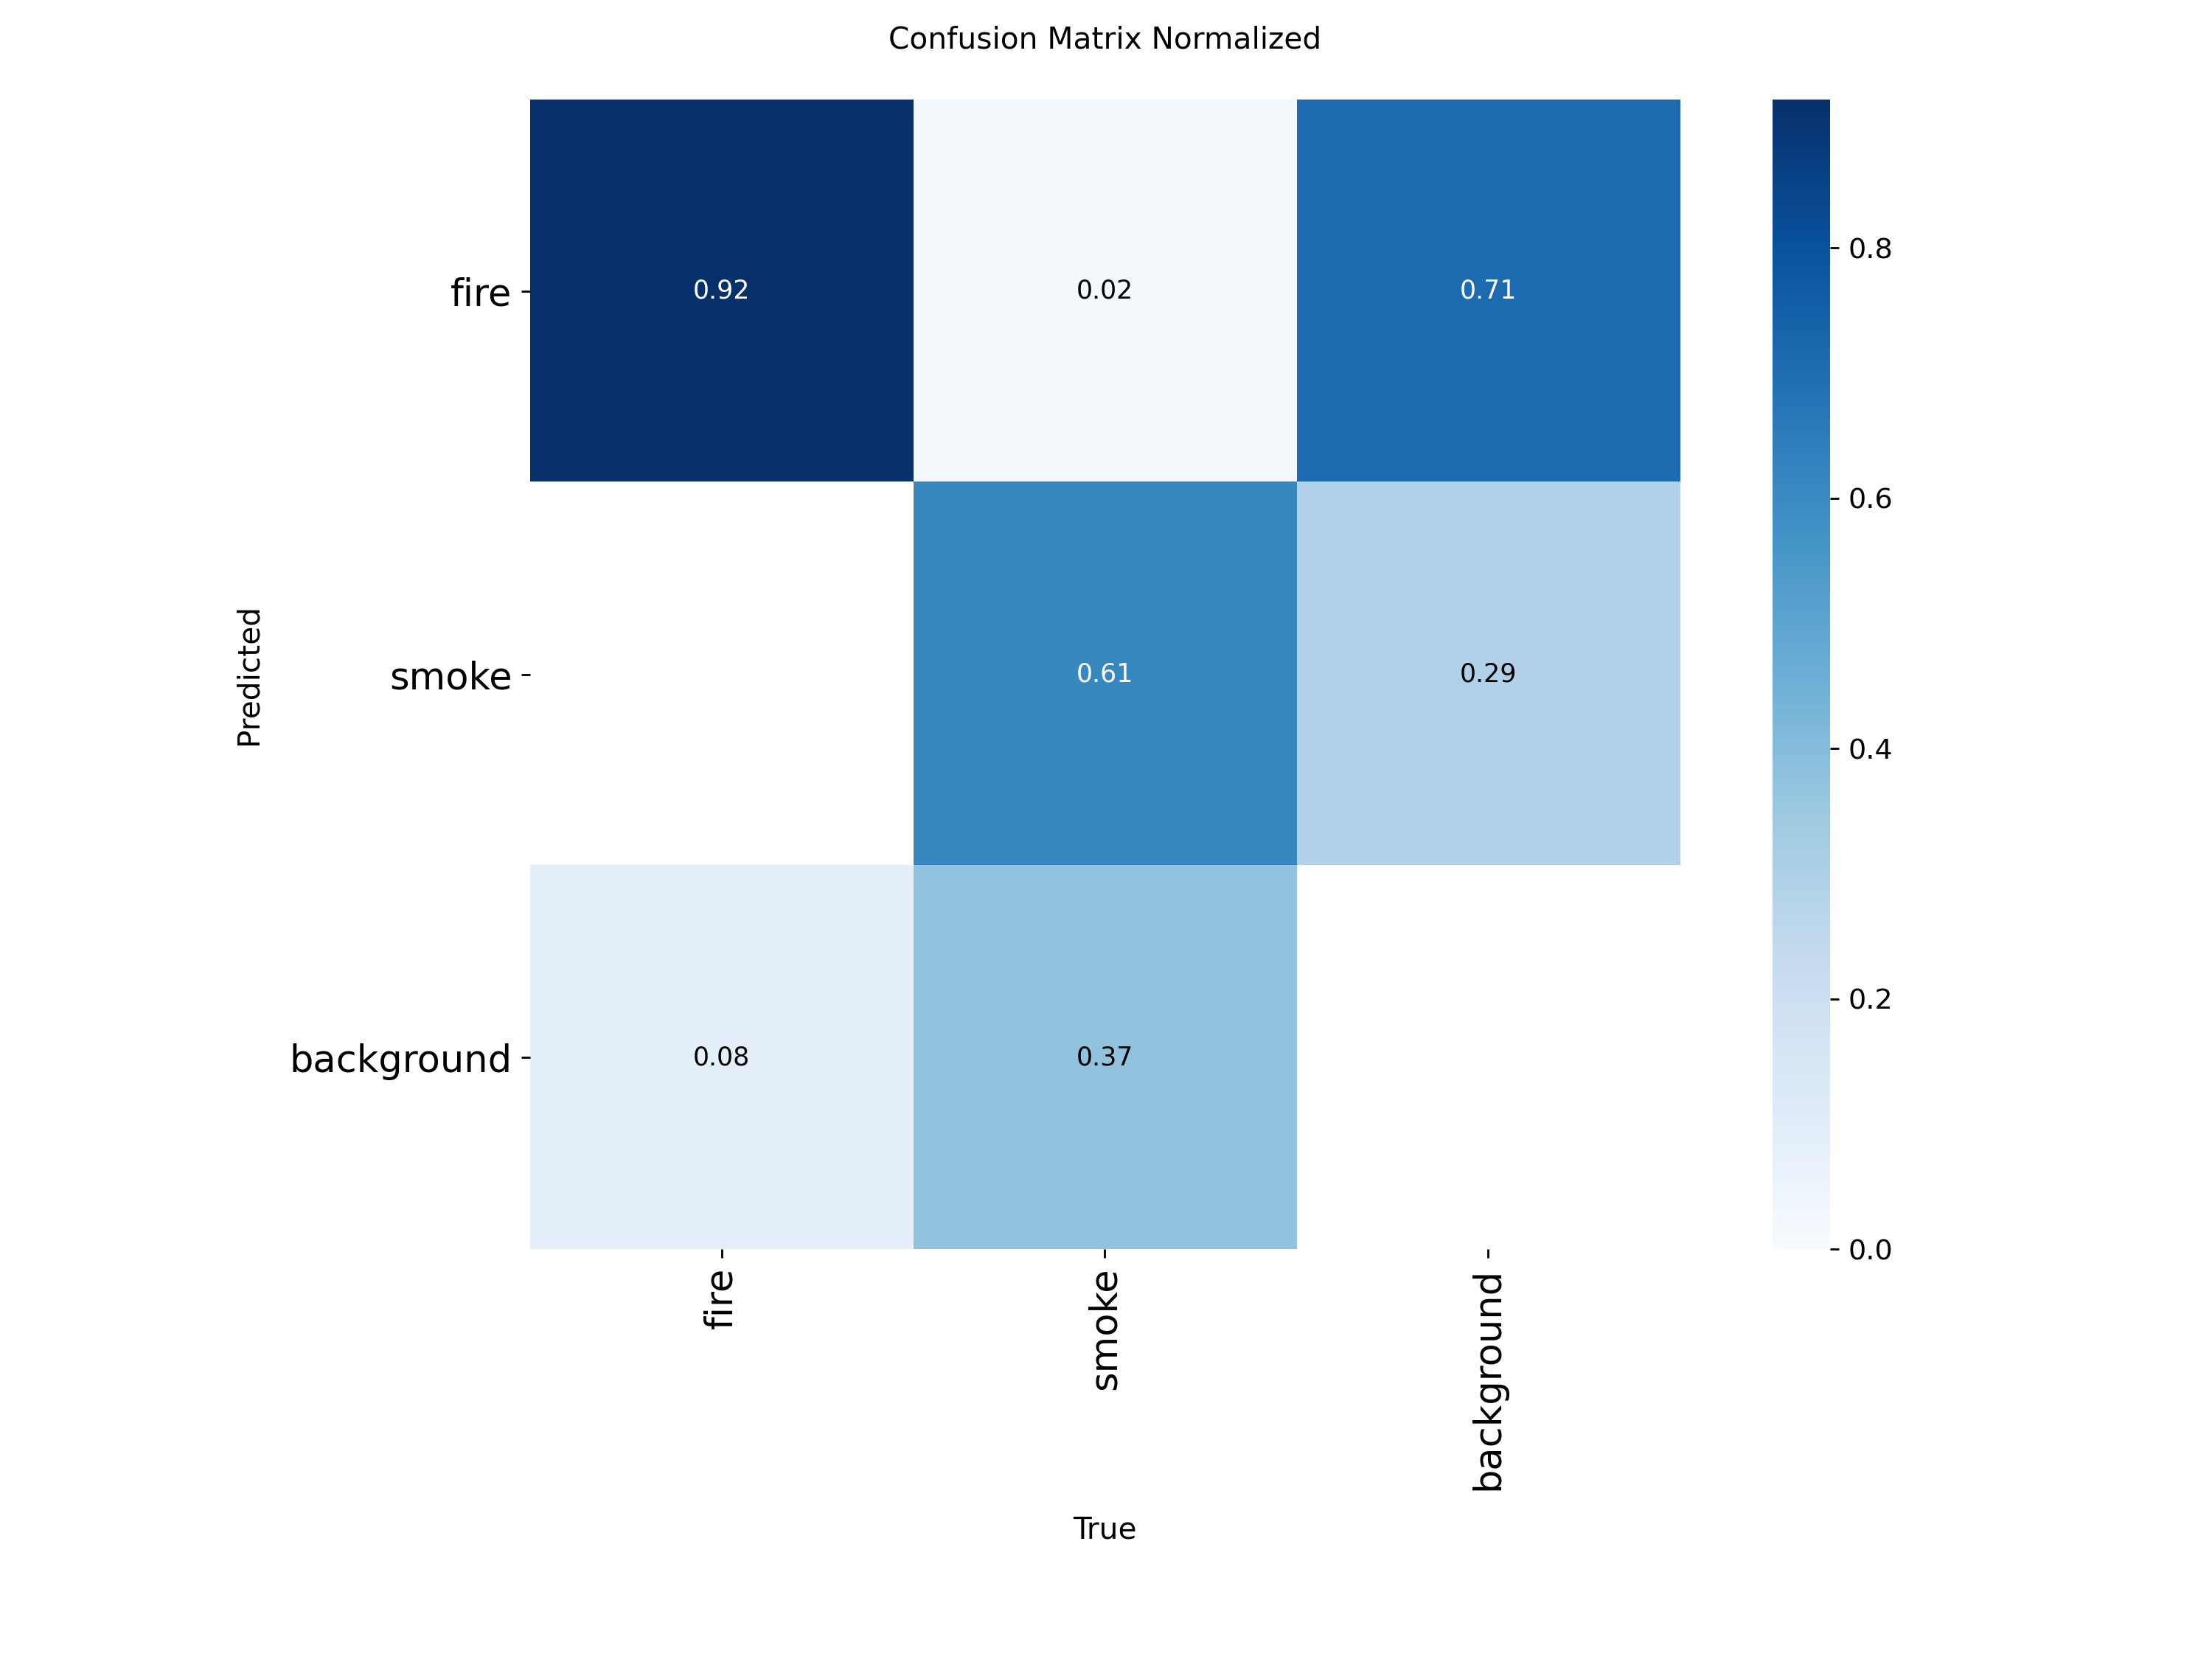

--------------------------------------------------
📊 results.png:


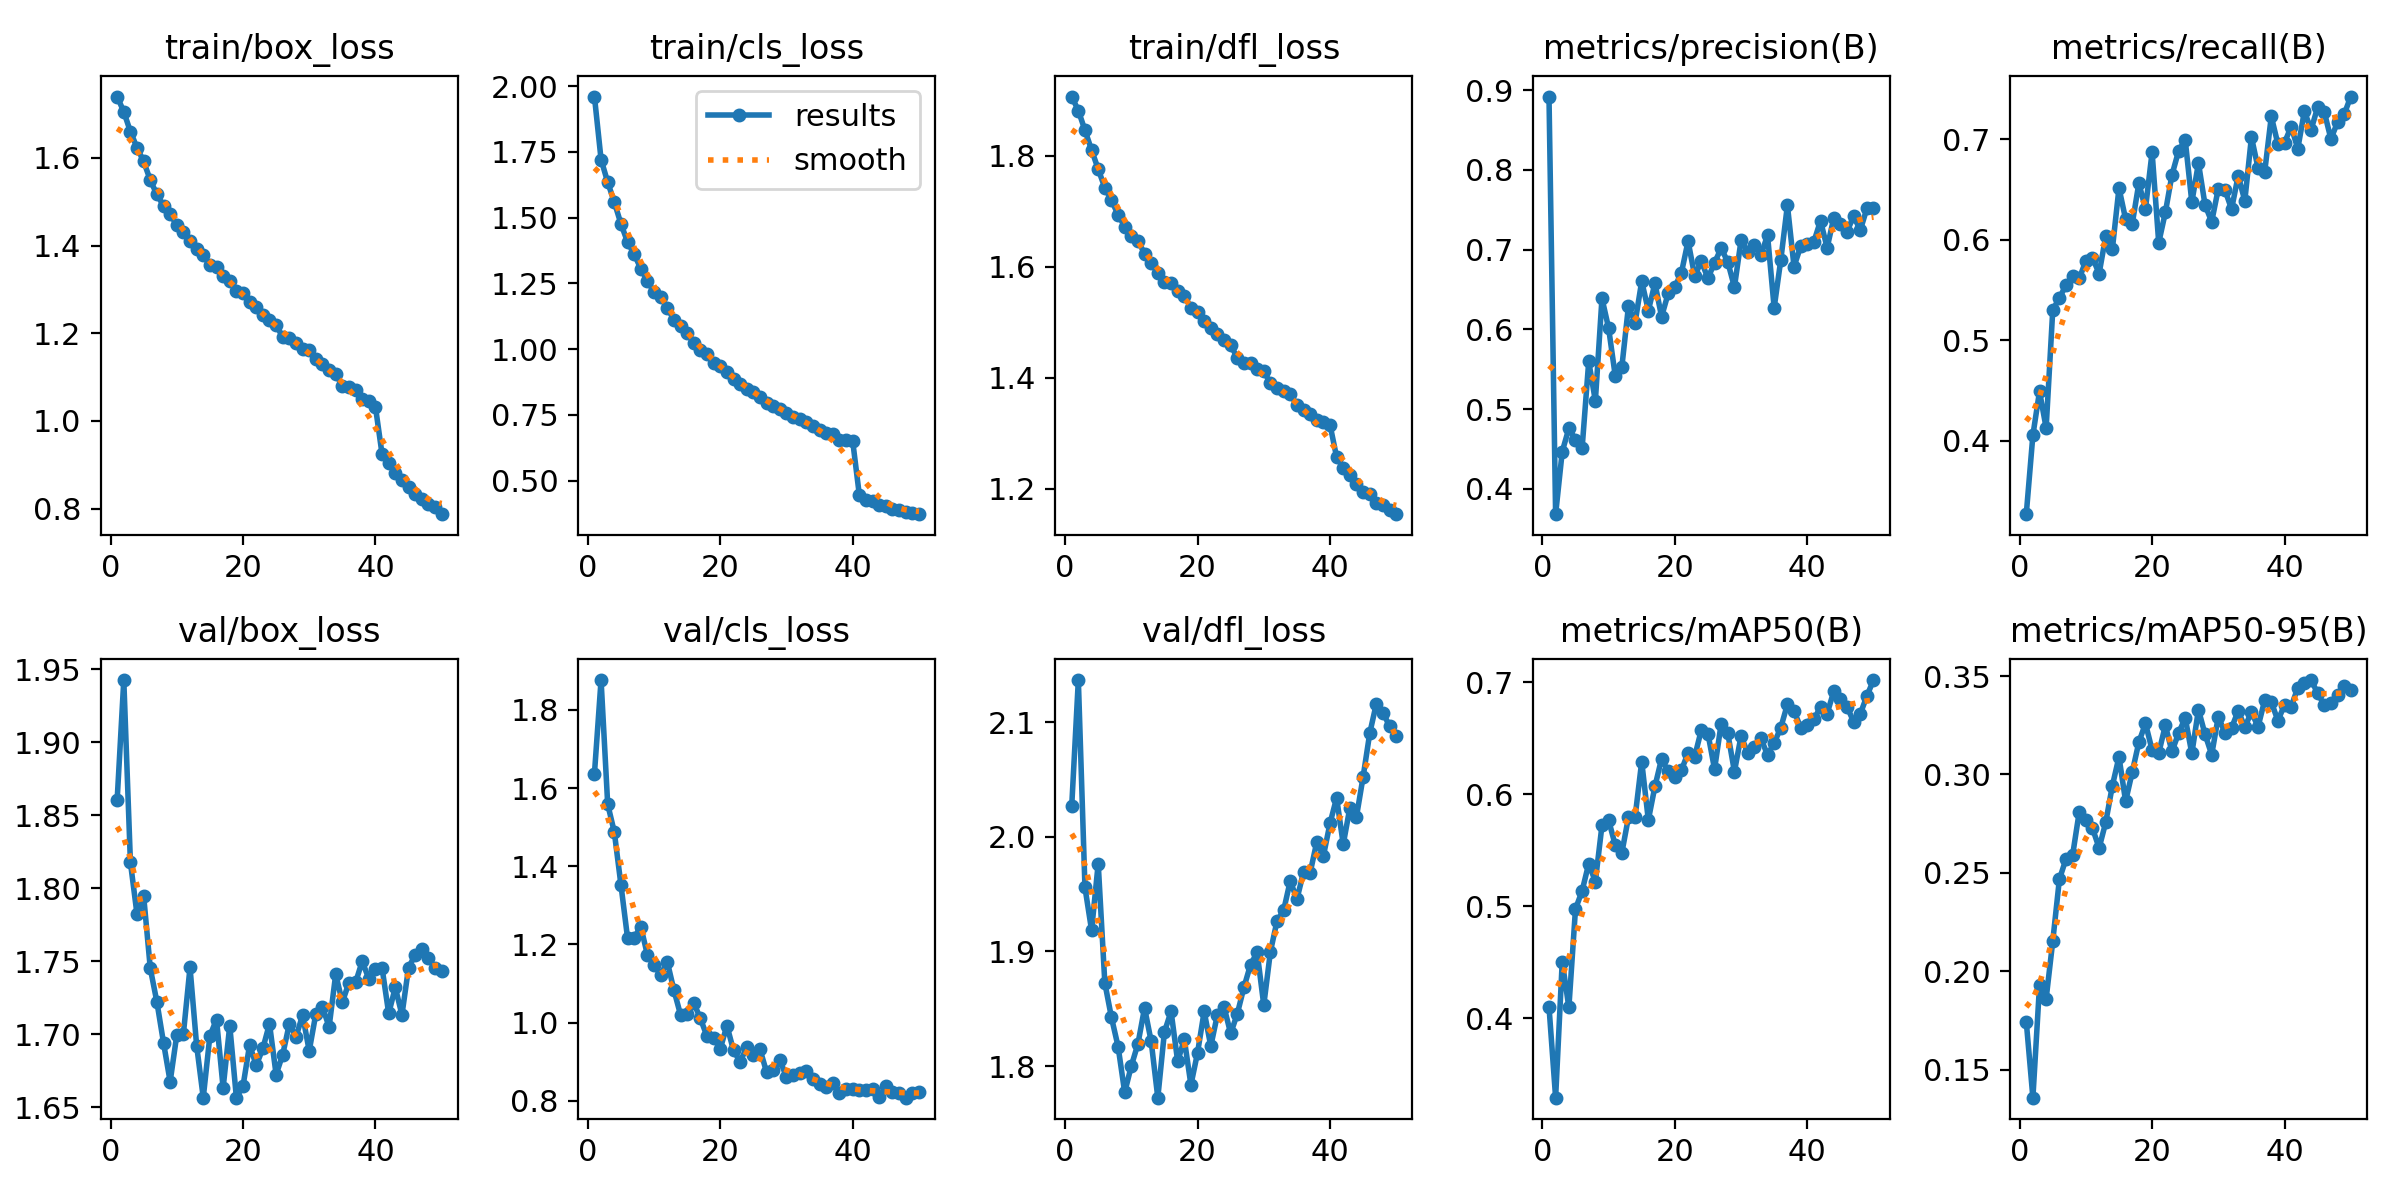

--------------------------------------------------
⚠️ الصورة PR_curve.png غير موجودة في المجلد.
⚠️ الصورة F1_curve.png غير موجودة في المجلد.


In [ ]:
from IPython.display import Image, display
import os

# مسار مجلد النتائج
runs_dir = '/content/runs/detect/fire_smoke_v2'

# قائمة الصور المهمة للتقييم
plots = [
    'confusion_matrix.png',         # مصفوفة الارتباك العادية
    'confusion_matrix_normalized.png', # مصفوفة الارتباك المعيرة (نسب مئوية)
    'results.png',                  # منحنيات الخسارة (Loss) و mAP عبر الحقب
    'PR_curve.png',                 # منحنى Precision-Recall
    'F1_curve.png'                  # منحنى F1-Score
]

# عرض الصور المتاحة
for plot in plots:
    img_path = os.path.join(runs_dir, plot)
    if os.path.exists(img_path):
        print(f"📊 {plot}:")
        display(Image(filename=img_path))
        print("-" * 50)
    else:
        print(f"⚠️ الصورة {plot} غير موجودة في المجلد.")

## 11 · Weights produced by this notebook

| File on Drive | Run | Epochs | Optimiser |
|---|---|---|---|
| `weights/run1_20ep.pt` | 1 | 20 | auto (SGD) |
| `weights/run2_v2_50ep.pt` | 2 | 50 | AdamW |

Both were downloaded from the Colab session, renamed, and uploaded to
`MyDrive/YOLO11_Fire_Smoke/weights/`.

Which of the two is actually better is **not** decided here. Training-set and
validation-set numbers are not enough — both runs are scored on the held-out
test split at the start of notebook 02, and the result there was not the one
expected.

**Continue in `02_Evaluation_Calibration_and_Demo.ipynb`.**